In [1]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty")  # <<< updated path here to refer to the implementation
import Utils
import Inject_Missing_Values
import imputers
import Gain
import MIWAE
import time


In [ ]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty")  # <<< updated path here to refer to the implementation
import Utils
import Inject_Missing_Values
import imputers
import Gain
import MIWAE
import time
import SoftImpute
import TabCSDI


In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from Inject_Missing_Values import *
from imputers import *
from imputers_updated import *
from Utils import *
from Gain import *
from MIWAE import *
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from SoftImpute import softimpute, cv_softimpute
from TabCSDI import TabCSDIImputer


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time


In [ ]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)
import torch.nn as nn

Loading the data

In [ ]:
data = fetch_openml(name="wine", version=2, as_frame=True)
X_full = data.data.copy()

In [ ]:
print(X_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malic_acid                    178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  OD280/OD315_of_diluted_wines  178 non-null    float64
 12  Proline                       178 non-null    int64  
dtypes: fl

Scalling the data to min-max scale

In [ ]:
scaler = MinMaxScaler() #data [0,1] #giving better result
X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

#scaler = StandardScaler()
#X_full =  pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

Storing the clean data as Ground Truth

In [ ]:
GroundTruth = X_full.copy()
X = X_full.copy()
print(GroundTruth)

      Alcohol  Malic_acid       Ash  Alcalinity_of_ash  Magnesium  \
0    0.842105    0.191700  0.572193           0.257732   0.619565   
1    0.571053    0.205534  0.417112           0.030928   0.326087   
2    0.560526    0.320158  0.700535           0.412371   0.336957   
3    0.878947    0.239130  0.609626           0.319588   0.467391   
4    0.581579    0.365613  0.807487           0.536082   0.521739   
..        ...         ...       ...                ...        ...   
173  0.705263    0.970356  0.582888           0.510309   0.271739   
174  0.623684    0.626482  0.598930           0.639175   0.347826   
175  0.589474    0.699605  0.481283           0.484536   0.543478   
176  0.563158    0.365613  0.540107           0.484536   0.543478   
177  0.815789    0.664032  0.737968           0.716495   0.282609   

     Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
0         0.627586    0.573840              0.283019         0.593060   
1         0.575862    0.5

Converting GroundTruth to tensor

In [ ]:
GroundTruth_tensor = torch.tensor(GroundTruth.values, dtype=torch.double)

In [ ]:
GroundTruth.nunique()

Alcohol                         126
Malic_acid                      133
Ash                              79
Alcalinity_of_ash                63
Magnesium                        53
Total_phenols                    97
Flavanoids                      132
Nonflavanoid_phenols             39
Proanthocyanins                 101
Color_intensity                 132
Hue                              78
OD280/OD315_of_diluted_wines    122
Proline                         121
dtype: int64

In [ ]:
print("Alcohol",GroundTruth['Alcohol'].unique())
print("Malic_acid",GroundTruth['Malic_acid'].unique())
print("Ash",GroundTruth['Ash'].unique())
print("Alcalinity_of_ash",GroundTruth['Alcalinity_of_ash'].unique())
print("Magnesium",GroundTruth["Magnesium"].unique())
print("Total_phenols",GroundTruth['Total_phenols'].unique())
print("Flavanoids",GroundTruth['Flavanoids'].unique())
print("Nonflavanoid_phenols",GroundTruth['Nonflavanoid_phenols'].unique())
print("Proanthocyanins",GroundTruth['Proanthocyanins'].unique())
print("Color_intensity",GroundTruth['Color_intensity'].unique())
print("Hue",GroundTruth['Hue'].unique())
print("OD280/OD315_of_diluted_wines",GroundTruth['OD280/OD315_of_diluted_wines'].unique())
print("Proline",GroundTruth['Proline'].unique())

Alcohol [0.84210526 0.57105263 0.56052632 0.87894737 0.58157895 0.83421053
 0.88421053 0.79736842 1.         0.74473684 0.80789474 0.81315789
 0.71578947 0.97894737 0.88157895 0.68421053 0.86052632 0.73684211
 0.83157895 0.68684211 0.5        0.70526316 0.47894737 0.65
 0.53157895 0.62105263 0.59736842 0.74736842 0.78684211 0.71052632
 0.67105263 0.69736842 0.71842105 0.65263158 0.64473684 0.59210526
 0.53684211 0.83947368 0.66578947 0.62631579 0.75       0.83684211
 0.75526316 0.76578947 0.73421053 0.72105263 0.71315789 0.59473684
 0.70789474 0.35263158 0.34210526 0.42368421 0.69473684 0.3
 0.54736842 0.60789474 0.31052632 0.33157895 0.64736842 0.51578947
 0.24473684 0.16578947 0.52631579 0.21315789 0.43947368 0.25526316
 0.44473684 0.27631579 0.43157895 0.29736842 0.16315789 0.16052632
 0.43684211 0.15526316 0.37894737 0.20526316 0.41315789 0.34473684
 0.20789474 0.38947368 0.36578947 0.32105263 0.31315789 0.15263158
 0.11315789 0.39210526 0.19210526 0.1        0.         0.45789474


Dependecies for MAR & MNAR

In [ ]:
mean_alcohol = GroundTruth["Alcohol"].mean()
median_malic = GroundTruth["Malic_acid"].median()
mean_ash = GroundTruth["Ash"].mean()
median_alcalinity = GroundTruth["Alcalinity_of_ash"].median()
mean_magnesium = GroundTruth["Magnesium"].mean()
median_phenols = GroundTruth["Total_phenols"].median()
mean_flavanoids = GroundTruth["Flavanoids"].mean()
median_nonflavanoid = GroundTruth["Nonflavanoid_phenols"].median()
mean_proanthocyanins = GroundTruth["Proanthocyanins"].mean()
median_color = GroundTruth["Color_intensity"].median()
mean_hue = GroundTruth["Hue"].mean()
median_od280 = GroundTruth["OD280/OD315_of_diluted_wines"].median()
mean_proline = GroundTruth["Proline"].mean()


dependencies_mar = {
    "Malic_acid": {
        "influencers": ["Alcohol"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] > mean_alcohol else 0.1
    },
    "Ash": {
        "influencers": ["Malic_acid"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] < median_malic else 0.1
    },
    "Alcalinity_of_ash": {
        "influencers": ["Ash"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Ash"] > mean_ash else 0.1
    },
    "Magnesium": {
        "influencers": ["Total_phenols"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Total_phenols"] < median_phenols else 0.1
    },
    "Total_phenols": {
        "influencers": ["Color_intensity"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] > median_color else 0.1
    },
    "Flavanoids": {
        "influencers": ["Malic_acid"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] < median_malic else 0.1
    },
    "Nonflavanoid_phenols": {
        "influencers": ["Flavanoids"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Flavanoids"] > mean_flavanoids else 0.1
    },
    "Proanthocyanins": {
        "influencers": ["Nonflavanoid_phenols"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Nonflavanoid_phenols"] < median_nonflavanoid else 0.1
    },
    "Color_intensity": {
        "influencers": ["Alcohol"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] > mean_alcohol else 0.1
    },
    "Hue": {
        "influencers": ["Color_intensity"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] > median_color else 0.1
    },
    "OD280/OD315_of_diluted_wines": {
        "influencers": ["Hue"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Hue"] < median_color else 0.1
    },
    "Proline": {
        "influencers": ["OD280/OD315_of_diluted_wines"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["OD280/OD315_of_diluted_wines"] > median_od280 else 0.1
    },
    "Alcohol": {
        "influencers": ["Proline"],  # Adding this as MAR (if you're okay with it having missingness)
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proline"] > mean_proline else 0.1
    }
}



In [ ]:
mean_alcohol = GroundTruth["Alcohol"].mean()
median_malic = GroundTruth["Malic_acid"].median()
mean_ash = GroundTruth["Ash"].mean()
median_alcalinity = GroundTruth["Alcalinity_of_ash"].median()
mean_magnesium = GroundTruth["Magnesium"].mean()
median_phenols = GroundTruth["Total_phenols"].median()
median_flav = GroundTruth["Flavanoids"].median()
median_nonflav = GroundTruth["Nonflavanoid_phenols"].median()
mean_proanthocyanins = GroundTruth["Proanthocyanins"].mean()
median_color = GroundTruth["Color_intensity"].median()
mean_hue = GroundTruth["Hue"].mean()
median_od280 = GroundTruth["OD280/OD315_of_diluted_wines"].median()
mean_proline = GroundTruth["Proline"].mean()

dependencies_mnar = {
    "Alcohol": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] < mean_alcohol else 0.1
    },
    "Malic_acid": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] == median_malic else 0.1
    },
    "Ash": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Ash"] >= mean_ash else 0.1
    },
    "Alcalinity_of_ash": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcalinity_of_ash"] <= median_alcalinity else 0.1
    },
    "Magnesium": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Magnesium"] >= mean_magnesium else 0.1
    },
    "Total_phenols": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Total_phenols"] <= median_phenols else 0.1
    },
    "Flavanoids": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Flavanoids"] == median_flav else 0.1
    },
    "Nonflavanoid_phenols": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Nonflavanoid_phenols"] <= median_nonflav else 0.1
    },
    "Proanthocyanins": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proanthocyanins"] < mean_proanthocyanins else 0.1
    },
    "Color_intensity": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] <= median_color else 0.1
    },
    "Hue": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Hue"] >= mean_hue else 0.1
    },
    "OD280/OD315_of_diluted_wines": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["OD280/OD315_of_diluted_wines"] >= median_od280 else 0.1
    },
    "Proline": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proline"] <= mean_proline else 0.1
    }
}


## MCAR

Running all the algorithms multiple runs 5 times, sample runs 50 times

In [ ]:

missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing


rng = np.random.default_rng(42)


# Create nested results dictionary
results_mcar = []
result_mae = []


for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mcar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 300, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
   
    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
    "Algorithm": "OT-Impute",
    "MissingRate": missing_rate,
    "MAE": OT_mae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mcar)
        #X_imputed_mice = X_imputed_tensor_mice.numpy()
        imputed_runs_mice.append(X_imputed_mice)

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    #print(imputed_std_mice)

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MICE",
    "MissingRate": missing_rate,
    "MAE": mice_mae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })


    #SoftImpute 
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mcar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
    
    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "SoftImpute",
    "MissingRate": missing_rate,
    "MAE": mae_soft  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_soft[missing_mask.values].flatten(),
                    imputed_std_soft[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    

    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mcar.copy()
        #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=1500)
        X_imputed_miwae = imputer.fit_transform(miss_mcar)

        imputed_runs_miwae.append(X_imputed_miwae)
        

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MIWAE",
    "MissingRate": missing_rate,
    "MAE": mae_miwae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })


    #GAIN
    t_method_start = time.perf_counter()
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=2500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
        #print(imputed_std_vae)

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "GAIN",
    "MissingRate": missing_rate,
    "MAE": mae_gain  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=10, epochs=2000)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mcar, return_std=True, inference_K=20)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries


    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "MIWAE-S",
    "MissingRate": missing_rate,
    "MAE": mae_miwaes  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    #GAIN
    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=5000, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-S",
    "MissingRate": missing_rate,
    "MAE": mae_gains  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    t_method_start = time.perf_counter()
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaeu = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=5, epochs=2000)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mcar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "MIWAE-U",
    "MissingRate": missing_rate,
    "MAE": mae_miwaeu  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mcar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    t_method_start = time.perf_counter()
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=2500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-U",
    "MissingRate": missing_rate,
    "MAE": mae_gainu  # This is the single number stored once
})
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })


    print("TabCSDI")
    t_method_start = time.perf_counter()
    imputed_runs_tab = []
    for i in range(runs):
        print(f"Run {i+1}...")
        tab = TabCSDIImputer(
            epochs=1200,
            nsamples=1,          # how many posterior draws to average
            num_steps=600,        # diffusion timesteps
            timeemb=128, featureemb=128,
            channels=64, layers=6, nheads=4,  # keep is_linear=False to avoid extra deps
            seed=None
        )
        X_imputed_tab = tab.fit_transform(miss_mcar.to_numpy())   # numpy out
        imputed_runs_tab.append(X_imputed_tab)

    imputed_stack_tab = np.stack(imputed_runs_tab, axis=0)
    imputed_mean_tab  = np.nanmean(imputed_stack_tab, axis=0)
    imputed_std_tab   = np.nanstd(imputed_stack_tab, axis=0)
    total_time_sec    = time.perf_counter() - t_method_start

    tab_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_tab[missing_mask.values]
    )
    result_mae.append({"Algorithm":"TabCSDI","MissingRate":missing_rate,"MAE":tab_mae})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_tab[missing_mask.values].flatten(),
                    imputed_std_tab[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm":"TabCSDI","MissingRate":missing_rate,"Time":total_time_sec,
            "TrueValue":t,"ImputedMean":m,"ImputedStd":s
        })
        
    print("TabCSDI-S")
    t_method_start = time.perf_counter()
    tabS = TabCSDIImputer(
            epochs=1200,
            nsamples=50,          # how many posterior draws to average
            num_steps=600,        # diffusion timesteps
            timeemb=128, featureemb=128,
            channels=64, layers=6, nheads=4,  # keep is_linear=False to avoid extra deps
            seed=None
        )
    tabS.fit(miss_mcar)
    mean_tabS, std_tabS = tabS.transform_with_std(miss_mcar, num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start

    mae_tabS = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_tabS[missing_mask.values]
        )
    result_mae.append({"Algorithm":"TabCSDI-S","MissingRate":missing_rate,"MAE":mae_tabS})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_tabS[missing_mask.values].flatten(),
                        std_tabS[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm":"TabCSDI-S","MissingRate":missing_rate,"Time":total_time_sec,
                "TrueValue":t,"ImputedMean":m,"ImputedStd":s
            })

    

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_results_with_all_missing_values.csv", index=False)

10
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
TabCSDI
Run 1...
[   1/1200] loss=0.979257
[ 120/1200] loss=0.187916
[ 240/1200] loss=0.129011
[ 360/1200] loss=0.104155
[ 480/1200] loss=0.089327
[ 600/1200] loss=0.090008
[ 720/1200] loss=0.086910
[ 840/1200] loss=0.075347
[ 960/1200] loss=0.101049
[1080/1200] loss=0.118989
[1200/1200] loss=0.094993
Run 2...
[   1/1200] loss=1.003286
[ 120/1200] loss=0.183675
[ 240/1200] loss=0.166459
[ 360/1200] loss=0.128334
[ 480/1200] loss=0.109858
[ 600/1200] loss=0.137875
[ 720/1200] loss=0.145605
[ 840/1200] loss=0.115875
[ 960/1200] loss=0.103074
[1080/1200] loss=0.080573
[1200/1200] loss=0.086989
Run 3...
[   1/1200] loss=0.958061
[ 120/1200] loss=0.120224
[ 240/1200] loss=0.173989
[ 360/1200] loss=0.1

In [ ]:
result_mae

[{'Algorithm': 'OT-Impute',
  'MissingRate': np.int64(10),
  'MAE': np.float64(0.10908249451601132)},
 {'Algorithm': 'MICE',
  'MissingRate': np.int64(10),
  'MAE': np.float64(0.12832046879598555)},
 {'Algorithm': 'SoftImpute',
  'MissingRate': np.int64(10),
  'MAE': np.float64(0.12490127552288881)},
 {'Algorithm': 'MIWAE',
  'MissingRate': np.int64(10),
  'MAE': np.float64(0.12821082522086918)},
 {'Algorithm': 'GAIN',
  'MissingRate': np.int64(10),
  'MAE': np.float64(0.1765137748522626)},
 {'Algorithm': 'MIWAE-S',
  'MissingRate': np.int64(10),
  'MAE': np.float64(0.13314723843967816)},
 {'Algorithm': 'GAIN-S',
  'MissingRate': np.int64(10),
  'MAE': np.float64(0.16885805484514552)},
 {'Algorithm': 'MIWAE-U',
  'MissingRate': np.int64(10),
  'MAE': np.float64(0.14767909531219378)},
 {'Algorithm': 'GAIN-U',
  'MissingRate': np.int64(10),
  'MAE': np.float64(0.2041384642779668)},
 {'Algorithm': 'TabCSDI',
  'MissingRate': np.int64(10),
  'MAE': np.float64(0.19637689615835535)},
 {'Algo

Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mcar = Inject_Missing_Values()
    miss_mcar, _ = generator_mcar.MCAR(X, missing_rate=missing_rate)
    missing_mask = miss_mcar.isna()
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    X_missing = miss_mcar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute","MIWAE", "GAIN","TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=300, batchsize=64)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=1500)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=2500, batch_size=512)
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mcar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute((missng_soft), lbda)[1]

            elif algo == "TabCSDI":
                imputer = TabCSDIImputer(
            epochs=1200,
            nsamples=1,          # how many posterior draws to average
            num_steps=600,        # diffusion timesteps
            timeemb=128, featureemb=128,
            channels=64, layers=6, nheads=4,  # keep is_linear=False to avoid extra deps
            seed=None
        )
                imputed = imputer.fit_transform(miss_mcar.to_numpy()) 
                
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_results_progressive_multiiple_run.csv", index=False)





=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

Multiple Sample Run

In [ ]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [10,20,30,40,50,60,70,80,90,100]

# Create nested results dictionary
results_mcar = []
runs=3


for missing_rate in missing_rates:
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
       
    missing_mask = miss_mcar.isna()
   
    imputer_gain = GAINImputer(epochs=2500, batch_size=512)
    X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
            miwae = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2000)
            mean_miwae, std_miwae= miwae.fit_transform_std(miss_mcar, return_std=True, inference_K=sample)

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                    
                })

            #GAIN
            print("GAIN-S")
            imputer_gain = GAINImputer(epochs=2500, batch_size=512)
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                    results_mcar.append({
                        "Algorithm": "GAIN-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })

            print("TabCSDI-S")
    
            tabS = TabCSDIImputer(
                    epochs=1200,
                    nsamples=50,          # how many posterior draws to average
                    num_steps=600,        # diffusion timesteps
                    timeemb=128, featureemb=128,
                    channels=64, layers=6, nheads=4,  # keep is_linear=False to avoid extra deps
                    seed=None
                )
            tabS.fit(miss_mcar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mcar, num_samples=20)
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_tabS[missing_mask.values].flatten(),
                            std_tabS[missing_mask.values].flatten()):
                    results_mcar.append({
                        "Algorithm": "TabCSDI-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })
        



df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_results_sample_runs.csv", index=False)

30
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S


MIWAE-U, Multiple run MIWAE and MIWAE-S

In [ ]:
missing_rate = 30 # 10% to 90% missing

runs = 4
rng = np.random.default_rng(42)
miwae_results_mcar = []
generator_mcar = Inject_Missing_Values()
miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
missing_mask = miss_mcar.isna()
it = 3
for j in range(it):
    #MIWAE
    imputed_runs_miwae = []
    print("MIWAE")
    for i in range(runs):
            print(f"Run {i+1}...")
            
            #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

            # 2. Instantiate your VAE
            imputer = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                                hidden_dims=[64, 64], K=5, epochs=2000)
            X_imputed_miwae = imputer.fit_transform(miss_mcar)

            imputed_runs_miwae.append(X_imputed_miwae)

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    std_miwae = np.nanstd(imputed_stack_miwae, axis=0)

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                miwae_results_mcar.append({
                    "Algorithm": "MIWAE",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                    
                })
    
    print("MIWAE-S")
    
    # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=5, epochs=2000)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mcar, return_std=True, inference_K=50)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
           miwae_results_mcar.append({
                "Algorithm": "MIWAE-S",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                
            })

    
    print("MIWAE-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaeu = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=5, epochs=2000)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mcar, return_std=True, inference_K=1)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           miwae_results_mcar.append({
                    "Algorithm": "MIWAE-U",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                
            })

df_results = pd.DataFrame(miwae_results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_miwae_comparision.csv", index=False)

MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
MIWAE-U
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
MIWAE-U
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
MIWAE-U


GAIN-U, Multiple run GAIN and GAIN-S

In [ ]:
missing_rate = 30 # 10% to 90% missing

runs = 4
rng = np.random.default_rng(42)
gain_results_mcar = []
generator_mcar = Inject_Missing_Values()
miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)

missing_mask = miss_mcar.isna()
it = 3
for j in range(it):
    #GAIN
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=5000, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    std_gain = np.nanstd(imputed_stack_gain, axis=0)
    

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                gain_results_mcar.append({
                    "Algorithm": "GAIN",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                    
                })
    
    print("GAIN-S")
    
    # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gains = GAINImputer(epochs=5000, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
  
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                gain_results_mcar.append({
                    "Algorithm": "GAIN-S",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    
    print("GAIN-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=5000, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                gain_results_mcar.append({
                    "Algorithm": "GAIN-U",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

df_results = pd.DataFrame(gain_results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_gain_comparision.csv", index=False)

GAIN
Run 1...
Run 2...
Run 3...
Run 4...
GAIN-S
GAIN-U
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
GAIN-S
GAIN-U
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
GAIN-S
GAIN-U


## MAR

Running all the algorithms multiple runs 5 times, sample runs 50 times

In [ ]:

missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing


rng = np.random.default_rng(42)


# Create nested results dictionary
results_mar = []
result_mae = []


for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 300, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
   
    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
    "Algorithm": "OT-Impute",
    "MissingRate": missing_rate,
    "MAE": OT_mae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mar)
        #X_imputed_mice = X_imputed_tensor_mice.numpy()
        imputed_runs_mice.append(X_imputed_mice)

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    #print(imputed_std_mice)

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MICE",
    "MissingRate": missing_rate,
    "MAE": mice_mae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })


    #SoftImpute 
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
    
    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "SoftImpute",
    "MissingRate": missing_rate,
    "MAE": mae_soft  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_soft[missing_mask.values].flatten(),
                    imputed_std_soft[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    

    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mar.copy()
        #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=1500)
        X_imputed_miwae = imputer.fit_transform(miss_mar)

        imputed_runs_miwae.append(X_imputed_miwae)
        

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MIWAE",
    "MissingRate": missing_rate,
    "MAE": mae_miwae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })


    #GAIN
    t_method_start = time.perf_counter()
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=2500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
        #print(imputed_std_vae)

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "GAIN",
    "MissingRate": missing_rate,
    "MAE": mae_gain  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=10, epochs=2000)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mar, return_std=True, inference_K=20)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries


    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "MIWAE-S",
    "MissingRate": missing_rate,
    "MAE": mae_miwaes  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    #GAIN
    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=5000, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-S",
    "MissingRate": missing_rate,
    "MAE": mae_gains  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    t_method_start = time.perf_counter()
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaeu = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=5, epochs=2000)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "MIWAE-U",
    "MissingRate": missing_rate,
    "MAE": mae_miwaeu  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    t_method_start = time.perf_counter()
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=2500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-U",
    "MissingRate": missing_rate,
    "MAE": mae_gainu  # This is the single number stored once
})
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })


    print("TabCSDI")
    t_method_start = time.perf_counter()
    imputed_runs_tab = []
    for i in range(runs):
        print(f"Run {i+1}...")
        tab = TabCSDIImputer(
            epochs=1200,
            nsamples=1,          # how many posterior draws to average
            num_steps=600,        # diffusion timesteps
            timeemb=128, featureemb=128,
            channels=64, layers=6, nheads=4,  # keep is_linear=False to avoid extra deps
            seed=42+i
        )
        X_imputed_tab = tab.fit_transform(miss_mar.to_numpy())   # numpy out
        imputed_runs_tab.append(X_imputed_tab)

    imputed_stack_tab = np.stack(imputed_runs_tab, axis=0)
    imputed_mean_tab  = np.nanmean(imputed_stack_tab, axis=0)
    imputed_std_tab   = np.nanstd(imputed_stack_tab, axis=0)
    total_time_sec    = time.perf_counter() - t_method_start

    tab_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_tab[missing_mask.values]
    )
    result_mae.append({"Algorithm":"TabCSDI","MissingRate":missing_rate,"MAE":tab_mae})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_tab[missing_mask.values].flatten(),
                    imputed_std_tab[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm":"TabCSDI","MissingRate":missing_rate,"Time":total_time_sec,
            "TrueValue":t,"ImputedMean":m,"ImputedStd":s
        })
        
    print("TabCSDI-S")
    t_method_start = time.perf_counter()
    tabS = TabCSDIImputer(
            epochs=1200,
            nsamples=50,          # how many posterior draws to average
            num_steps=600,        # diffusion timesteps
            timeemb=128, featureemb=128,
            channels=64, layers=6, nheads=4,  # keep is_linear=False to avoid extra deps
            seed=42+i
        )
    tabS.fit(miss_mar)
    mean_tabS, std_tabS = tabS.transform_with_std(miss_mar, num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start

    mae_tabS = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_tabS[missing_mask.values]
        )
    result_mae.append({"Algorithm":"TabCSDI-S","MissingRate":missing_rate,"MAE":mae_tabS})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_tabS[missing_mask.values].flatten(),
                        std_tabS[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm":"TabCSDI-S","MissingRate":missing_rate,"Time":total_time_sec,
                "TrueValue":t,"ImputedMean":m,"ImputedStd":s
            })

    

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_results_with_all_missing_values.csv", index=False)

10
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
20
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
40
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
50
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
GAIN-S


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\zhossai3\\Desktop\\Uncertainty\\imputation_Uncertainty\\Output\\results\\Wine_mar_allMethod_mae.csv'

Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mar = Inject_Missing_Values()
    miss_mar, _ = generator_mar.MAR(X, missing_rate=missing_rate,dependencies=dependencies_mar)
    missing_mask = miss_mar.isna()
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    X_missing = miss_mar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute","MIWAE", "GAIN","TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=300, batchsize=64)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=1500)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=2500, batch_size=512)
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute((missng_soft), lbda)[1]

            elif algo == "TabCSDI":
                imputer = TabCSDIImputer(
            epochs=1200,
            nsamples=1,          # how many posterior draws to average
            num_steps=600,        # diffusion timesteps
            timeemb=128, featureemb=128,
            channels=64, layers=6, nheads=4,  # keep is_linear=False to avoid extra deps
            seed=42+i
        )
                imputed = imputer.fit_transform(miss_mar.to_numpy()) 
                
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_results_progressive_multiiple_run.csv", index=False)





=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...


Multiple Sample Run

In [ ]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [10,20,30,40,50,60,70,80,90,100]

# Create nested results dictionary
results_mar = []
runs=3


for missing_rate in missing_rates:
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
       
    missing_mask = miss_mar.isna()
   
    imputer_gain = GAINImputer(epochs=2500, batch_size=512)
    X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
            miwae = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2000)
            mean_miwae, std_miwae= miwae.fit_transform_std(miss_mar, return_std=True, inference_K=sample)

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                    
                })

            #GAIN
            print("GAIN-S")
            imputer_gain = GAINImputer(epochs=2500, batch_size=512)
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                    results_mar.append({
                        "Algorithm": "GAIN-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })

            print("TabCSDI-S")
    
            tabS = TabCSDIImputer(
                    epochs=1200,
                    nsamples=50,          # how many posterior draws to average
                    num_steps=600,        # diffusion timesteps
                    timeemb=128, featureemb=128,
                    channels=64, layers=6, nheads=4,  # keep is_linear=False to avoid extra deps
                    seed=42+i
                )
            tabS.fit(miss_mar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mar, num_samples=20)
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_tabS[missing_mask.values].flatten(),
                            std_tabS[missing_mask.values].flatten()):
                    results_mar.append({
                        "Algorithm": "TabCSDI-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })
        



df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_results_sample_runs.csv", index=False)

30
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S


MIWAE-U, Multiple run MIWAE and MIWAE-S

In [ ]:
missing_rate = 30 # 10% to 90% missing

runs = 4
rng = np.random.default_rng(42)
miwae_results_mar = []
generator_mar = Inject_Missing_Values()
miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
missing_mask = miss_mar.isna()
it = 3
for j in range(it):
    #MIWAE
    imputed_runs_miwae = []
    print("MIWAE")
    for i in range(runs):
            print(f"Run {i+1}...")
            
            #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

            # 2. Instantiate your VAE
            imputer = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                                hidden_dims=[64, 64], K=5, epochs=2000)
            X_imputed_miwae = imputer.fit_transform(miss_mar)

            imputed_runs_miwae.append(X_imputed_miwae)

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    std_miwae = np.nanstd(imputed_stack_miwae, axis=0)

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                miwae_results_mar.append({
                    "Algorithm": "MIWAE",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                    
                })
    
    print("MIWAE-S")
    
    # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=5, epochs=2000)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mar, return_std=True, inference_K=50)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
           miwae_results_mar.append({
                "Algorithm": "MIWAE-S",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                
            })

    
    print("MIWAE-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaeu = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=5, epochs=2000)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mar, return_std=True, inference_K=1)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           miwae_results_mar.append({
                    "Algorithm": "MIWAE-U",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                
            })

df_results = pd.DataFrame(miwae_results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_miwae_comparision.csv", index=False)

MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
MIWAE-U
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
MIWAE-U
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
MIWAE-U


GAIN-U, Multiple run GAIN and GAIN-S

In [ ]:
missing_rate = 30 # 10% to 90% missing

runs = 4
rng = np.random.default_rng(42)
gain_results_mar = []
generator_mar = Inject_Missing_Values()
miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)

missing_mask = miss_mar.isna()
it = 3
for j in range(it):
    #GAIN
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=5000, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    std_gain = np.nanstd(imputed_stack_gain, axis=0)
    

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                gain_results_mar.append({
                    "Algorithm": "GAIN",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                    
                })
    
    print("GAIN-S")
    
    # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gains = GAINImputer(epochs=5000, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
  
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                gain_results_mar.append({
                    "Algorithm": "GAIN-S",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    
    print("GAIN-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=5000, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                gain_results_mar.append({
                    "Algorithm": "GAIN-U",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

df_results = pd.DataFrame(gain_results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_gain_comparision.csv", index=False)

GAIN
Run 1...


Run 2...
Run 3...
Run 4...
GAIN-S
GAIN-U
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
GAIN-S
GAIN-U
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
GAIN-S
GAIN-U


## MNAR

Running all the algorithms multiple runs 5 times, sample runs 50 times

In [ ]:

missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing


rng = np.random.default_rng(42)


# Create nested results dictionary
results_mnar = []
result_mae = []


for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mnar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 300, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
   
    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
    "Algorithm": "OT-Impute",
    "MissingRate": missing_rate,
    "MAE": OT_mae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mnar)
        #X_imputed_mice = X_imputed_tensor_mice.numpy()
        imputed_runs_mice.append(X_imputed_mice)

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    #print(imputed_std_mice)

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MICE",
    "MissingRate": missing_rate,
    "MAE": mice_mae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })


    #SoftImpute 
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mnar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
    
    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "SoftImpute",
    "MissingRate": missing_rate,
    "MAE": mae_soft  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_soft[missing_mask.values].flatten(),
                    imputed_std_soft[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    

    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mnar.copy()
        #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=1500)
        X_imputed_miwae = imputer.fit_transform(miss_mnar)

        imputed_runs_miwae.append(X_imputed_miwae)
        

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MIWAE",
    "MissingRate": missing_rate,
    "MAE": mae_miwae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })


    #GAIN
    t_method_start = time.perf_counter()
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=2500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
        #print(imputed_std_vae)

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "GAIN",
    "MissingRate": missing_rate,
    "MAE": mae_gain  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=10, epochs=2000)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mnar, return_std=True, inference_K=20)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries


    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "MIWAE-S",
    "MissingRate": missing_rate,
    "MAE": mae_miwaes  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    #GAIN
    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=5000, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-S",
    "MissingRate": missing_rate,
    "MAE": mae_gains  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    t_method_start = time.perf_counter()
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaeu = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=5, epochs=2000)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mnar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "MIWAE-U",
    "MissingRate": missing_rate,
    "MAE": mae_miwaeu  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mnar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    t_method_start = time.perf_counter()
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=2500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-U",
    "MissingRate": missing_rate,
    "MAE": mae_gainu  # This is the single number stored once
})
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })


    print("TabCSDI")
    t_method_start = time.perf_counter()
    imputed_runs_tab = []
    for i in range(runs):
        print(f"Run {i+1}...")
        tab = TabCSDIImputer(
            epochs=1200,
            nsamples=1,          # how many posterior draws to average
            num_steps=600,        # diffusion timesteps
            timeemb=128, featureemb=128,
            channels=64, layers=6, nheads=4,  # keep is_linear=False to avoid extra deps
            seed=42+i
        )
        X_imputed_tab = tab.fit_transform(miss_mnar.to_numpy())   # numpy out
        imputed_runs_tab.append(X_imputed_tab)

    imputed_stack_tab = np.stack(imputed_runs_tab, axis=0)
    imputed_mean_tab  = np.nanmean(imputed_stack_tab, axis=0)
    imputed_std_tab   = np.nanstd(imputed_stack_tab, axis=0)
    total_time_sec    = time.perf_counter() - t_method_start

    tab_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_tab[missing_mask.values]
    )
    result_mae.append({"Algorithm":"TabCSDI","MissingRate":missing_rate,"MAE":tab_mae})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_tab[missing_mask.values].flatten(),
                    imputed_std_tab[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm":"TabCSDI","MissingRate":missing_rate,"Time":total_time_sec,
            "TrueValue":t,"ImputedMean":m,"ImputedStd":s
        })
        
    print("TabCSDI-S")
    t_method_start = time.perf_counter()
    tabS = TabCSDIImputer(
            epochs=1200,
            nsamples=50,          # how many posterior draws to average
            num_steps=600,        # diffusion timesteps
            timeemb=128, featureemb=128,
            channels=64, layers=6, nheads=4,  # keep is_linear=False to avoid extra deps
            seed=42+i
        )
    tabS.fit(miss_mnar)
    mean_tabS, std_tabS = tabS.transform_with_std(miss_mnar, num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start

    mae_tabS = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_tabS[missing_mask.values]
        )
    result_mae.append({"Algorithm":"TabCSDI-S","MissingRate":missing_rate,"MAE":mae_tabS})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_tabS[missing_mask.values].flatten(),
                        std_tabS[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm":"TabCSDI-S","MissingRate":missing_rate,"Time":total_time_sec,
                "TrueValue":t,"ImputedMean":m,"ImputedStd":s
            })

    

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_results_with_all_missing_values.csv", index=False)

10
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
20
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
40
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
50
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
GAIN-S


Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mnar = Inject_Missing_Values()
    miss_mnar, _ = generator_mnar.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
    missing_mask = miss_mnar.isna()
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    X_missing = miss_mnar.copy()

    algorithms = ["OT-Impute", "MICE", "MIWAE", "GAIN"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=300, batchsize=64)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=50, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=5, epochs=2000)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=5000, batch_size=512)
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mnar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute((missng_soft), lbda)[1]

            elif algo == "TabCSDI":
                imputer = TabCSDIImputer(
            epochs=1200,
            nsamples=1,          # how many posterior draws to average
            num_steps=600,        # diffusion timesteps
            timeemb=128, featureemb=128,
            channels=64, layers=6, nheads=4,  # keep is_linear=False to avoid extra deps
            seed=42+i
        )
                imputed = imputer.fit_transform(miss_mnar.to_numpy()) 
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_results_progressive_multiiple_run.csv", index=False)





=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...


Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...


Multiple Sample Run

In [ ]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [10,20,30,40,50,60,70,80,90,100]

# Create nested results dictionary
results_mnar = []
runs=3


for missing_rate in missing_rates:
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
       
    missing_mask = miss_mnar.isna()
    miwae = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=5, epochs=2000)
    imputer_gain = GAINImputer(epochs=5000, batch_size=512)
    X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
           
            mean_miwae, std_miwae= miwae.fit_transform_std(miss_mnar, return_std=True, inference_K=sample)

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                    
                })

            #GAIN
            print("GAIN-S")
         
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                    results_mnar.append({
                        "Algorithm": "GAIN-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })

            
            print("TabCSDI-S")
    
            tabS = TabCSDIImputer(
                    epochs=1200,
                    nsamples=50,          # how many posterior draws to average
                    num_steps=600,        # diffusion timesteps
                    timeemb=128, featureemb=128,
                    channels=64, layers=6, nheads=4,  # keep is_linear=False to avoid extra deps
                    seed=42+i
                )
            tabS.fit(miss_mar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mar, num_samples=20)
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_tabS[missing_mask.values].flatten(),
                            std_tabS[missing_mask.values].flatten()):
                    results_mar.append({
                        "Algorithm": "TabCSDI-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })
        



df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_results_sample_runs.csv", index=False)

30


10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S


MIWAE-U, Multiple run MIWAE and MIWAE-S

In [ ]:
missing_rate = 30 # 10% to 90% missing

runs = 4
rng = np.random.default_rng(42)
miwae_results_mnar = []
generator_mnar = Inject_Missing_Values()
miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
missing_mask = miss_mnar.isna()
it = 3
for j in range(it):
    #MIWAE
    imputed_runs_miwae = []
    print("MIWAE")
    for i in range(runs):
            print(f"Run {i+1}...")
            
            #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

            # 2. Instantiate your VAE
            imputer = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                                hidden_dims=[64, 64], K=5, epochs=2000)
            X_imputed_miwae = imputer.fit_transform(miss_mnar)

            imputed_runs_miwae.append(X_imputed_miwae)

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    std_miwae = np.nanstd(imputed_stack_miwae, axis=0)

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                miwae_results_mnar.append({
                    "Algorithm": "MIWAE",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                    
                })
    
    print("MIWAE-S")
    
    # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                       hidden_dims=[64, 64], K=5, epochs=2000)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mnar, return_std=True, inference_K=50)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
           miwae_results_mnar.append({
                "Algorithm": "MIWAE-S",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                
            })

    
    print("MIWAE-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaeu = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                      hidden_dims=[64, 64], K=5, epochs=2000)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mnar, return_std=True, inference_K=1)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           miwae_results_mnar.append({
                    "Algorithm": "MIWAE-U",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                
            })

df_results = pd.DataFrame(miwae_results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_miwae_comparision.csv", index=False)

MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
MIWAE-U
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
MIWAE-U
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE-S
MIWAE-U


GAIN-U, Multiple run GAIN and GAIN-S

In [ ]:
missing_rate = 30 # 10% to 90% missing

runs = 4
rng = np.random.default_rng(42)
gain_results_mnar = []
generator_mnar = Inject_Missing_Values()
miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)

missing_mask = miss_mnar.isna()
it = 3
for j in range(it):
    #GAIN
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=5000, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    std_gain = np.nanstd(imputed_stack_gain, axis=0)
    

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                gain_results_mnar.append({
                    "Algorithm": "GAIN",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                    
                })
    
    print("GAIN-S")
    
    # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gains = GAINImputer(epochs=5000, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
  
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                gain_results_mnar.append({
                    "Algorithm": "GAIN-S",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    
    print("GAIN-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=5000, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                gain_results_mnar.append({
                    "Algorithm": "GAIN-U",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

df_results = pd.DataFrame(gain_results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_gain_comparision.csv", index=False)

GAIN
Run 1...


Run 2...
Run 3...
Run 4...
GAIN-S
GAIN-U
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
GAIN-S
GAIN-U
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
GAIN-S
GAIN-U


Entropy Attribute Calculation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine


wine_df = X_full

def attribute_entropy(column, bins=10):
    counts, _ = np.histogram(column, bins=bins)
    probs = counts / counts.sum()
    probs = probs[probs > 0]  # remove zeros to avoid log(0)
    entropy = -np.sum(probs * np.log2(probs))
    return entropy

# Compute entropy for each attribute
entropy_dict = {col: attribute_entropy(wine_df[col]) for col in wine_df.columns}
entropy_df = pd.DataFrame.from_dict(entropy_dict, orient='index', columns=['Entropy']).sort_values(by='Entropy', ascending=False)

print(entropy_df)


                               Entropy
OD280/OD315_of_diluted_wines  3.141197
Nonflavanoid_phenols          3.099088
Alcohol                       3.027361
Total_phenols                 3.018772
Proline                       2.969275
Flavanoids                    2.886313
Hue                           2.867960
Color_intensity               2.863514
Malic_acid                    2.834222
Proanthocyanins               2.822579
Alcalinity_of_ash             2.782049
Ash                           2.596092
Magnesium                     2.589284


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# === Load your imputation results ===

highest_attr_idx = "OD280/OD315_of_diluted_wines"  # replace with your highest-entropy attribute index
lowest_attr_idx  = "Magnesium" 

def calibration_curve(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

def compute_ece(true_values, imputed_mean, imputed_std):
    quantiles, proportions = calibration_curve(true_values, imputed_mean, imputed_std)
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece, quantiles, proportions

def ece_for_attribute(df, missing_rate, idx):
    results = {}
    for algo in df["Algorithm"].unique():
        subset = df[(df["MissingRate"] == missing_rate) & (df["Algorithm"] == algo)]
        print(subset["ImputedMean"])
        print(type(subset["ImputedMean"]))
        true_values = np.array(list(subset["TrueValue"]))
        imputed_mean = np.array(list(subset["ImputedMean"]))
        imputed_std  = np.array(list(subset["ImputedStd"]))
        
        # Take only the column for the attribute
        true_col = true_values[:, idx]
        mean_col = imputed_mean[:, idx]
        std_col  = imputed_std[:, idx]

       
                
        ece = compute_ece(true_col,mean_col ,std_col)
                              
        results[algo] = ece
    return results

highest_idx = X.columns.get_loc(highest_attr_idx)
lowest_idx = X.columns.get_loc(lowest_attr_idx)


### MCAR

In [ ]:
import numpy as np
import torch


def run_gain_s(X):
    imputer = GAINImputer(epochs=100, batch_size=128)
    imputer.fit_transform(X)           # train and impute once
    return imputer.sample(num_samples=50)  # return mean, std


missing_rate = 30
runs = 4  # for stochastic methods

rng = np.random.default_rng(42)

# Generate MCAR missing data
generator_mcar = Inject_Missing_Values()
miss_mcar, _ = generator_mcar.MCAR(X, missing_rate=missing_rate)
missing_mask = miss_mcar.isna()
mask_np = missing_mask.values.astype(bool)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)

# Store ECE results
results_entropy = []

# Define all methods
methods = {
    "OT-Impute": lambda X: OTimputer(niter=100, batchsize=128).fit_transform(X),
    "MICE": lambda X: IterativeImputer(max_iter=100, sample_posterior=True).fit_transform(X),
    "MIWAE": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform(X),
    "MIWAE-S": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform_std(X, return_std=True, inference_K=50),
    "MIWAE-U": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform_std(X, return_std=True, inference_K=1),
    "GAIN": lambda X: GAINImputer(epochs=100, batch_size=128).fit_transform(X),
   "GAIN-S": lambda X:run_gain_s(X),
    "GAIN-U": lambda X: GAINU(epochs=100, batch_size=128).fit_transform_uncertainty(X),
}

# Methods that need multiple stochastic runs
multi_run_methods = ["OT-Impute", "MICE", "MIWAE", "GAIN"]

for method_name, impute_func in methods.items():
    print(f"\nRunning {method_name}...")

    n_runs = runs if method_name in multi_run_methods else 1
    imputed_runs = []

    for i in range(n_runs):
        print(f"Run {i+1}...")

        # Select input type
        input_data = X_missing_tensor if method_name in ["OT-Impute", "GAIN", "GAIN-S", "GAIN-U"] else miss_mcar

        result = impute_func(input_data)

        # Handle methods returning (mean, std)
        if isinstance(result, tuple):
            X_imputed, X_std = result
        else:
            X_imputed = result
            if torch.is_tensor(X_imputed):
                X_std = np.zeros_like(X_imputed.detach())  # placeholder
            else:
                X_std = np.zeros_like(X_imputed)

        # Convert tensors to numpy
        if torch.is_tensor(X_imputed):
            X_imputed = X_imputed.detach().numpy()
        if torch.is_tensor(X_std):
            X_std = X_std.detach().numpy()

        imputed_runs.append((X_imputed, X_std))

    # Stack results
    if n_runs > 1:
        imputed_stack = np.stack([m[0] for m in imputed_runs], axis=0)
        imputed_stack_std = np.stack([m[1] for m in imputed_runs], axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
    else:
        imputed_mean, imputed_std = imputed_runs[0]

    # Compute ECE for highest and lowest entropy attributes
    ece_high, quantiles_high, proportions_high = compute_ece(
        GroundTruth.values[:, highest_idx][missing_mask.iloc[:, highest_idx]],
        imputed_mean[:, highest_idx][missing_mask.iloc[:, highest_idx]],
        imputed_std[:, highest_idx][missing_mask.iloc[:, highest_idx]]
    )

    ece_low, quantiles_low, proportions_low = compute_ece(
        GroundTruth.values[:, lowest_idx][missing_mask.iloc[:, lowest_idx]],
        imputed_mean[:, lowest_idx][missing_mask.iloc[:, lowest_idx]],
        imputed_std[:, lowest_idx][missing_mask.iloc[:, lowest_idx]]
    )

    mask_high = missing_mask.iloc[:, highest_idx].values
    mask_low  = missing_mask.iloc[:, lowest_idx].values

        # Columns for GT and imputed means
    gt_high = GroundTruth.values[:, highest_idx]
    gt_low  = GroundTruth.values[:, lowest_idx]

    imp_high = imputed_mean[:, highest_idx]
    imp_low  = imputed_mean[:, lowest_idx]

        # Safe MAE (handle case where a column has no missing values)
        
    mae_high = mean_absolute_error(gt_high[mask_high],imp_high[mask_high])
        
    mae_low = mean_absolute_error(gt_low[mask_low],imp_low[mask_low])
        
    results_entropy.append({
            "Method": method_name,
            "MissingRate": missing_rate,
            "MissingType": "MCAR",
            "HighAtrECE": ece_high,
            "HighMae":mae_high,
            "LowAtrECE": ece_low,
            "LowMae":mae_low,
            "Quantiles_High": quantiles_high,
            "Proportions_High": proportions_high,
            "Quantiles_Low": quantiles_low,
            "Proportions_Low": proportions_low

        })



Running OT-Impute...
Run 1...
Run 2...
Run 3...
Run 4...

Running MICE...
Run 1...
Run 2...
Run 3...
Run 4...

Running MIWAE...
Run 1...
Run 2...
Run 3...
Run 4...

Running MIWAE-S...
Run 1...

Running MIWAE-U...
Run 1...

Running GAIN...
Run 1...
Run 2...
Run 3...
Run 4...

Running GAIN-S...
Run 1...

Running GAIN-U...
Run 1...


In [ ]:
import numpy as np
import torch


def run_gain_s(X):
    imputer = GAINImputer(epochs=100, batch_size=128)
    imputer.fit_transform(X)           # train and impute once
    return imputer.sample(num_samples=50)  # return mean, std


missing_rate = 30
runs = 4  # for stochastic methods

rng = np.random.default_rng(42)

# Generate MAR missing data
generator_mar = Inject_Missing_Values()
miss_mar, _ = generator_mar.MAR(X, missing_rate=missing_rate,dependencies=dependencies_mar)
missing_mask = miss_mar.isna()
mask_np = missing_mask.values.astype(bool)
X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)



# Define all methods
methods = {
    "OT-Impute": lambda X: OTimputer(niter=100, batchsize=128).fit_transform(X),
    "MICE": lambda X: IterativeImputer(max_iter=100, sample_posterior=True).fit_transform(X),
    "MIWAE": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform(X),
    "MIWAE-S": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform_std(X, return_std=True, inference_K=50),
    "MIWAE-U": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform_std(X, return_std=True, inference_K=1),
    "GAIN": lambda X: GAINImputer(epochs=100, batch_size=128).fit_transform(X),
   "GAIN-S": lambda X:run_gain_s(X),
    "GAIN-U": lambda X: GAINU(epochs=100, batch_size=128).fit_transform_uncertainty(X),
}

# Methods that need multiple stochastic runs
multi_run_methods = ["OT-Impute", "MICE", "MIWAE", "GAIN"]

for method_name, impute_func in methods.items():
    print(f"\nRunning {method_name}...")

    n_runs = runs if method_name in multi_run_methods else 1
    imputed_runs = []

    for i in range(n_runs):
        print(f"Run {i+1}...")

        # Select input type
        input_data = X_missing_tensor if method_name in ["OT-Impute", "GAIN", "GAIN-S", "GAIN-U"] else miss_mar

        result = impute_func(input_data)

        # Handle methods returning (mean, std)
        if isinstance(result, tuple):
            X_imputed, X_std = result
        else:
            X_imputed = result
            if torch.is_tensor(X_imputed):
                X_std = np.zeros_like(X_imputed.detach())  # placeholder
            else:
                X_std = np.zeros_like(X_imputed)

        # Convert tensors to numpy
        if torch.is_tensor(X_imputed):
            X_imputed = X_imputed.detach().numpy()
        if torch.is_tensor(X_std):
            X_std = X_std.detach().numpy()

        imputed_runs.append((X_imputed, X_std))

    # Stack results
    if n_runs > 1:
        imputed_stack = np.stack([m[0] for m in imputed_runs], axis=0)
        imputed_stack_std = np.stack([m[1] for m in imputed_runs], axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
    else:
        imputed_mean, imputed_std = imputed_runs[0]

    # Compute ECE for highest and lowest entropy attributes
    ece_high, quantiles_high, proportions_high = compute_ece(
        GroundTruth.values[:, highest_idx][missing_mask.iloc[:, highest_idx]],
        imputed_mean[:, highest_idx][missing_mask.iloc[:, highest_idx]],
        imputed_std[:, highest_idx][missing_mask.iloc[:, highest_idx]]
    )

    ece_low, quantiles_low, proportions_low = compute_ece(
        GroundTruth.values[:, lowest_idx][missing_mask.iloc[:, lowest_idx]],
        imputed_mean[:, lowest_idx][missing_mask.iloc[:, lowest_idx]],
        imputed_std[:, lowest_idx][missing_mask.iloc[:, lowest_idx]]
    )

    mask_high = missing_mask.iloc[:, highest_idx].values
    mask_low  = missing_mask.iloc[:, lowest_idx].values

    # Columns for GT and imputed means
    gt_high = GroundTruth.values[:, highest_idx]
    gt_low  = GroundTruth.values[:, lowest_idx]

    imp_high = imputed_mean[:, highest_idx]
    imp_low  = imputed_mean[:, lowest_idx]

    # Safe MAE (handle case where a column has no missing values)
    
    mae_high = mean_absolute_error(gt_high[mask_high],imp_high[mask_high])
    
    mae_low = mean_absolute_error(gt_low[mask_low],imp_low[mask_low])
    
    results_entropy.append({
        "Method": method_name,
        "MissingRate": missing_rate,
        "MissingType": "MAR",
        "HighAtrECE": ece_high,
        "HighMae":mae_high,
        "LowAtrECE": ece_low,
        "LowMae":mae_low,
        "Quantiles_High": quantiles_high,
        "Proportions_High": proportions_high,
        "Quantiles_Low": quantiles_low,
        "Proportions_Low": proportions_low

    })



Running OT-Impute...
Run 1...
Run 2...
Run 3...
Run 4...

Running MICE...
Run 1...
Run 2...
Run 3...
Run 4...

Running MIWAE...
Run 1...
Run 2...
Run 3...
Run 4...

Running MIWAE-S...
Run 1...

Running MIWAE-U...
Run 1...

Running GAIN...
Run 1...
Run 2...
Run 3...
Run 4...

Running GAIN-S...
Run 1...

Running GAIN-U...
Run 1...


In [ ]:
import numpy as np
import torch


def run_gain_s(X):
    imputer = GAINImputer(epochs=100, batch_size=128)
    imputer.fit_transform(X)           # train and impute once
    return imputer.sample(num_samples=50)  # return mean, std


missing_rate = 30
runs = 4  # for stochastic methods

rng = np.random.default_rng(42)

# Generate MNAR missing data
generator_mnar = Inject_Missing_Values()
miss_mnar, _ = generator_mnar.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
missing_mask = miss_mnar.isna()
mask_np = missing_mask.values.astype(bool)
X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)



# Define all methods
methods = {
    "OT-Impute": lambda X: OTimputer(niter=100, batchsize=128).fit_transform(X),
    "MICE": lambda X: IterativeImputer(max_iter=100, sample_posterior=True).fit_transform(X),
    "MIWAE": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform(X),
    "MIWAE-S": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform_std(X, return_std=True, inference_K=50),
    "MIWAE-U": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform_std(X, return_std=True, inference_K=1),
    "GAIN": lambda X: GAINImputer(epochs=100, batch_size=128).fit_transform(X),
   "GAIN-S": lambda X:run_gain_s(X),
    "GAIN-U": lambda X: GAINU(epochs=100, batch_size=128).fit_transform_uncertainty(X),
}

# Methods that need multiple stochastic runs
multi_run_methods = ["OT-Impute", "MICE", "MIWAE", "GAIN"]

for method_name, impute_func in methods.items():
    print(f"\nRunning {method_name}...")

    n_runs = runs if method_name in multi_run_methods else 1
    imputed_runs = []

    for i in range(n_runs):
        print(f"Run {i+1}...")

        # Select input type
        input_data = X_missing_tensor if method_name in ["OT-Impute", "GAIN", "GAIN-S", "GAIN-U"] else miss_mnar

        result = impute_func(input_data)

        # Handle methods returning (mean, std)
        if isinstance(result, tuple):
            X_imputed, X_std = result
        else:
            X_imputed = result
            if torch.is_tensor(X_imputed):
                X_std = np.zeros_like(X_imputed.detach())  # placeholder
            else:
                X_std = np.zeros_like(X_imputed)

        # Convert tensors to numpy
        if torch.is_tensor(X_imputed):
            X_imputed = X_imputed.detach().numpy()
        if torch.is_tensor(X_std):
            X_std = X_std.detach().numpy()

        imputed_runs.append((X_imputed, X_std))

    # Stack results
    if n_runs > 1:
        imputed_stack = np.stack([m[0] for m in imputed_runs], axis=0)
        imputed_stack_std = np.stack([m[1] for m in imputed_runs], axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
    else:
        imputed_mean, imputed_std = imputed_runs[0]

    # Compute ECE for highest and lowest entropy attributes
    ece_high, quantiles_high, proportions_high = compute_ece(
        GroundTruth.values[:, highest_idx][missing_mask.iloc[:, highest_idx]],
        imputed_mean[:, highest_idx][missing_mask.iloc[:, highest_idx]],
        imputed_std[:, highest_idx][missing_mask.iloc[:, highest_idx]]
    )

    ece_low, quantiles_low, proportions_low = compute_ece(
        GroundTruth.values[:, lowest_idx][missing_mask.iloc[:, lowest_idx]],
        imputed_mean[:, lowest_idx][missing_mask.iloc[:, lowest_idx]],
        imputed_std[:, lowest_idx][missing_mask.iloc[:, lowest_idx]]
    )

    mask_high = missing_mask.iloc[:, highest_idx].values
    mask_low  = missing_mask.iloc[:, lowest_idx].values

    # Columns for GT and imputed means
    gt_high = GroundTruth.values[:, highest_idx]
    gt_low  = GroundTruth.values[:, lowest_idx]

    imp_high = imputed_mean[:, highest_idx]
    imp_low  = imputed_mean[:, lowest_idx]

    # Safe MAE (handle case where a column has no missing values)
    
    mae_high = mean_absolute_error(gt_high[mask_high],imp_high[mask_high])
    
    mae_low = mean_absolute_error(gt_low[mask_low],imp_low[mask_low])
    
    results_entropy.append({
        "Method": method_name,
        "MissingRate": missing_rate,
        "MissingType": "MNAR",
        "HighAtrECE": ece_high,
        "HighMae":mae_high,
        "LowAtrECE": ece_low,
        "LowMae":mae_low,
        "Quantiles_High": quantiles_high,
        "Proportions_High": proportions_high,
        "Quantiles_Low": quantiles_low,
        "Proportions_Low": proportions_low

    })



Running OT-Impute...
Run 1...
Run 2...
Run 3...
Run 4...

Running MICE...
Run 1...
Run 2...
Run 3...
Run 4...

Running MIWAE...
Run 1...
Run 2...
Run 3...
Run 4...

Running MIWAE-S...
Run 1...

Running MIWAE-U...
Run 1...

Running GAIN...
Run 1...
Run 2...
Run 3...
Run 4...

Running GAIN-S...
Run 1...

Running GAIN-U...
Run 1...


In [ ]:
df = pd.DataFrame(results_entropy)

# Save to CSV
df.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_entropy.csv", index=False) 

ECE VS Model Iterations and MAE vs Model Iterations and time vs Model Iterations

In [ ]:
import numpy as np
import torch


def calibration_curve(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

def compute_ece(true_values, imputed_mean, imputed_std):
    quantiles, proportions = calibration_curve(true_values, imputed_mean, imputed_std)
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

def run_gain_s(X):
    imputer = GAINImputer(epochs=100, batch_size=128)
    imputer.fit_transform(X)           # train and impute once
    return imputer.sample(num_samples=50)  # return mean, std


missing_rate = 30
runs = 5  # for stochastic methods
iterations = [100,300,500,700,900]

rng = np.random.default_rng(42)

# Generate MCAR missing data
generator_mcar = Inject_Missing_Values()
miss_mcar, _ = generator_mcar.MCAR(X, missing_rate=missing_rate)
missing_mask = miss_mcar.isna()
mask_np = missing_mask.values.astype(bool)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)

results_mcar_ece = []
results_mcar_mae = []

for itr in iterations:
    # Define all methods
    methods = {
        "OT-Impute": lambda Y: OTimputer(niter=itr, batchsize=128).fit_transform(Y),
        "MICE": lambda Y: IterativeImputer(max_iter=itr, sample_posterior=True).fit_transform(Y),
        "MIWAE": lambda Y: MIWAEImputer(input_dim=Y.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=itr).fit_transform(Y),
        "GAIN": lambda Y: GAINImputer(epochs=itr, batch_size=128).fit_transform(Y),
    
    }

    # Methods that need multiple stochastic runs
    multi_run_methods = ["OT-Impute", "MICE", "MIWAE", "GAIN"]
    
    for method_name, impute_func in methods.items():
        print(f"\nRunning {method_name}...")
        imputed_runs = []
        t_method_start = time.perf_counter()
        for i in range(runs):
            print(f"Run {i+1}...")

            # Select input type
            input_data = X_missing_tensor if method_name in ["OT-Impute", "GAIN"] else miss_mcar

            
            result = impute_func(input_data)
            

            # Handle methods returning (mean, std)
            if isinstance(result, tuple):
                X_imputed, X_std = result
            else:
                X_imputed = result
                if torch.is_tensor(X_imputed):
                    X_std = np.zeros_like(X_imputed.detach())  # placeholder
                else:
                    X_std = np.zeros_like(X_imputed)

            # Convert tensors to numpy
            if torch.is_tensor(X_imputed):
                X_imputed = X_imputed.detach().numpy()
            if torch.is_tensor(X_std):
                X_std = X_std.detach().numpy()

            imputed_runs.append((X_imputed, X_std))
        
        total_time_sec = time.perf_counter() - t_method_start
        imputed_stack = np.stack([m[0] for m in imputed_runs], axis=0)
        imputed_stack_std = np.stack([m[1] for m in imputed_runs], axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
        

        # Compute ECE for highest and lowest entropy attributes
        ece = compute_ece(
            GroundTruth.values[missing_mask.values],
            imputed_mean[missing_mask.values],
            imputed_std[missing_mask.values]
        )

            
        mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean[missing_mask.values]
    )
            
            
        results_mcar_ece.append({
                "Method": method_name,
                "MissingRate": missing_rate,
                "MissingType": "MCAR",
                "Iteration":itr,
                "ECE": ece,
                "Time":  total_time_sec
                

            })
        
        results_mcar_mae.append({
            "Method": method_name,
            "MissingRate": missing_rate,
            "MissingType": "MCAR",
            "Iteration":itr,
            "MAE": mae,
            "Time":  total_time_sec

        })
df_mae = pd.DataFrame(results_mcar_mae)

# Save to CSV
df_mae.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_mae.csv", index=False) 
df_ece = pd.DataFrame(results_mcar_ece)

# Save to CSV
df_ece.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_ece.csv", index=False) 


Running OT-Impute...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running MICE...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running MIWAE...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running GAIN...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running OT-Impute...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running MICE...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running MIWAE...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running GAIN...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running OT-Impute...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running MICE...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running MIWAE...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running GAIN...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running OT-Impute...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running MICE...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running MIWAE...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Running GAIN...
Run 1...
Run 2...
Run 3...
Ru

In [ ]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [20,40,60,80,100]

# Create nested results dictionary
results_mcar = []




generator_mcar = Inject_Missing_Values()
miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
       
missing_mask = miss_mcar.isna()
miwae = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=20, epochs=100)
imputer_gain = GAINImputer(epochs=100, batch_size=128)
X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
    
for sample in samples:  
    print(sample) 

    print("MIWAE-S")   
    if torch.cuda.is_available(): torch.cuda.synchronize()            # optional for GPU accuracy
    t0 = time.perf_counter()  
    mean_miwae, std_miwae= miwae.fit_transform_std(miss_mcar, return_std=True, inference_K=sample)
    miwae_time = time.perf_counter() - t0
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwae[missing_mask.values])

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE-S",
                   
            "MissingRate": missing_rate,
            "Time":  miwae_time,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "Sample": sample,
            "MAE":mae_miwae
                    
                })

            #GAIN
    print("GAIN-S")
    if torch.cuda.is_available(): torch.cuda.synchronize()            # optional for GPU accuracy
    t0 = time.perf_counter()    
    mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
    gain_time = time.perf_counter() - t0

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gain[missing_mask.values])
            
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
        results_mcar.append({
                        "Algorithm": "GAIN-S",
                        "MissingRate": missing_rate,
                        "Time": gain_time,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample,
                        "MAE":mae_gain
                    })
        



df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_timeVSsamples.csv", index=False)

20
MIWAE-S


KeyboardInterrupt: 

In [ ]:
import numpy as np
import torch


def calibration_curve(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

def compute_ece(true_values, imputed_mean, imputed_std):
    quantiles, proportions = calibration_curve(true_values, imputed_mean, imputed_std)
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

def run_gain_s(X):
    imputer = GAINImputer(epochs=100, batch_size=128)
    imputer.fit_transform(X)           # train and impute once
    return imputer.sample(num_samples=50)  # return mean, std


missing_rate = 30
runs = 2  # for stochastic methods


rng = np.random.default_rng(42)

# Generate MCAR missing data
generator_mcar = Inject_Missing_Values()
miss_mcar, _ = generator_mcar.MCAR(X, missing_rate=missing_rate)
missing_mask = miss_mcar.isna()
mask_np = missing_mask.values.astype(bool)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)

results_mcar_ece = []
results_mcar_mae = []


    # Define all methods
methods = {
        "OT-Impute": lambda Y: OTimputer(niter=300, batchsize=128).fit_transform(Y),
        "MICE": lambda Y: IterativeImputer(max_iter=50, sample_posterior=True).fit_transform(Y),
        "MIWAE": lambda Y: MIWAEImputer(input_dim=Y.shape[1], latent_dim=10, hidden_dims=[64,64], K=5, epochs=2000).fit_transform(Y),
        "GAIN": lambda Y: GAINImputer(epochs=5000, batch_size=512).fit_transform(Y),
    }

    # Methods that need multiple stochastic runs
multi_run_methods = ["OT-Impute", "MICE", "MIWAE", "GAIN"]
    
for method_name, impute_func in methods.items():
        print(f"\nRunning {method_name}...")
        imputed_runs = []
        t_method_start = time.perf_counter()
        for i in range(runs):
            print(f"Run {i+1}...")

            # Select input type
            input_data = X_missing_tensor if method_name in ["OT-Impute", "GAIN"] else miss_mcar

            
            result = impute_func(input_data)
            

            # Handle methods returning (mean, std)
            if isinstance(result, tuple):
                X_imputed, X_std = result
            else:
                X_imputed = result
                if torch.is_tensor(X_imputed):
                    X_std = np.zeros_like(X_imputed.detach())  # placeholder
                else:
                    X_std = np.zeros_like(X_imputed)

            # Convert tensors to numpy
            if torch.is_tensor(X_imputed):
                X_imputed = X_imputed.detach().numpy()
            if torch.is_tensor(X_std):
                X_std = X_std.detach().numpy()

            imputed_runs.append((X_imputed, X_std))
        
        total_time_sec = time.perf_counter() - t_method_start
        imputed_stack = np.stack([m[0] for m in imputed_runs], axis=0)
        imputed_stack_std = np.stack([m[1] for m in imputed_runs], axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
        

        # Compute ECE for highest and lowest entropy attributes
        ece = compute_ece(
            GroundTruth.values[missing_mask.values],
            imputed_mean[missing_mask.values],
            imputed_std[missing_mask.values]
        )

            
        mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean[missing_mask.values]
    )
            
            
        results_mcar_ece.append({
                "Method": method_name,
                "MissingRate": missing_rate,
                "MissingType": "MCAR",
                "Iteration":10,
                "ECE": ece,
                "Time":  total_time_sec
                

            })
        
        results_mcar_mae.append({
            "Method": method_name,
            "MissingRate": missing_rate,
            "MissingType": "MCAR",
            "Iteration":10,
            "MAE": mae,
            "Time":  total_time_sec

        })
df_mae = pd.DataFrame(results_mcar_mae)

# Save to CSV
df_mae.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_mae_test.csv", index=False) 
df_ece = pd.DataFrame(results_mcar_ece)

# Save to CSV
df_ece.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_ece_test.csv", index=False) 


Running OT-Impute...
Run 1...
Run 2...

Running MICE...
Run 1...
Run 2...

Running MIWAE...
Run 1...
Run 2...

Running GAIN...
Run 1...
Run 2...


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# ===== Load CSV results (change path if needed) =====
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_ece_test.csv"
    # e.g., could also be your Energy file if it contains Iteration info
)

# Normalize column names if needed
if "Algorithm" not in df_results.columns and "Method" in df_results.columns:
    df_results = df_results.rename(columns={"Method": "Algorithm"})

# Keep MCAR only if present (optional)
if "MissingType" in df_results.columns:
    df_results = df_results[df_results["MissingType"] == "MCAR"].copy()

# Ensure numeric Iteration
if "Iteration" in df_results.columns:
    df_results["Iteration"] = pd.to_numeric(df_results["Iteration"], errors="coerce")

# --- If ECE isn't present, compute it per (Algorithm, Iteration) from per-point data ---
def compute_ece(true_vals, mean_vals, std_vals):
    std_safe = np.asarray(std_vals) + 1e-6
    cdf_vals = norm.cdf(np.asarray(true_vals), loc=np.asarray(mean_vals), scale=std_safe)
    qs = np.linspace(0, 1, 11)
    props = [(cdf_vals < q).mean() for q in qs]
    return float(np.abs(np.array(props) - qs).mean())

if "ECE" not in df_results.columns:
    required = {"Algorithm", "Iteration", "TrueValue", "ImputedMean", "ImputedStd"}
    if required.issubset(df_results.columns):
        ece_rows = []
        for (algo, itr), g in df_results.groupby(["Algorithm", "Iteration"]):
            ece_rows.append({
                "Algorithm": algo,
                "Iteration": itr,
                "ECE": compute_ece(g["TrueValue"].values, g["ImputedMean"].values, g["ImputedStd"].values),
            })
        df_results = pd.DataFrame(ece_rows)
    else:
        raise ValueError("CSV must contain ECE or per-point columns (TrueValue, ImputedMean, ImputedStd).")

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 16
legend_label_fontsize = 14
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute": {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":      {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "MIWAE":     {"color": "#27d62d", "marker": "D"},   # Green diamond
    "GAIN":      {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S":  {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U":  {"color": "#431271", "marker": "v"},
}

algorithms = df_results["Algorithm"].unique()

# ---- Plot: ECE vs Iteration (one line per algorithm) ----
plt.figure(figsize=(8, 8))
for algo in algorithms:
    # Skip S/U variants if you don't want them
    if algo in {"GAIN-S", "GAIN-U", "MIWAE-U", "MIWAE-S"}:
        continue

    g = df_results[df_results["Algorithm"] == algo].sort_values("Iteration")
    if g.empty:
        continue

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        g["Iteration"], g["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo,
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Iterations", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
#save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_ECE_vs_Iteration.pdf"
#plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

#print("Saved to:", save_path)


KeyError: 'Iteration'

<Figure size 800x800 with 0 Axes>

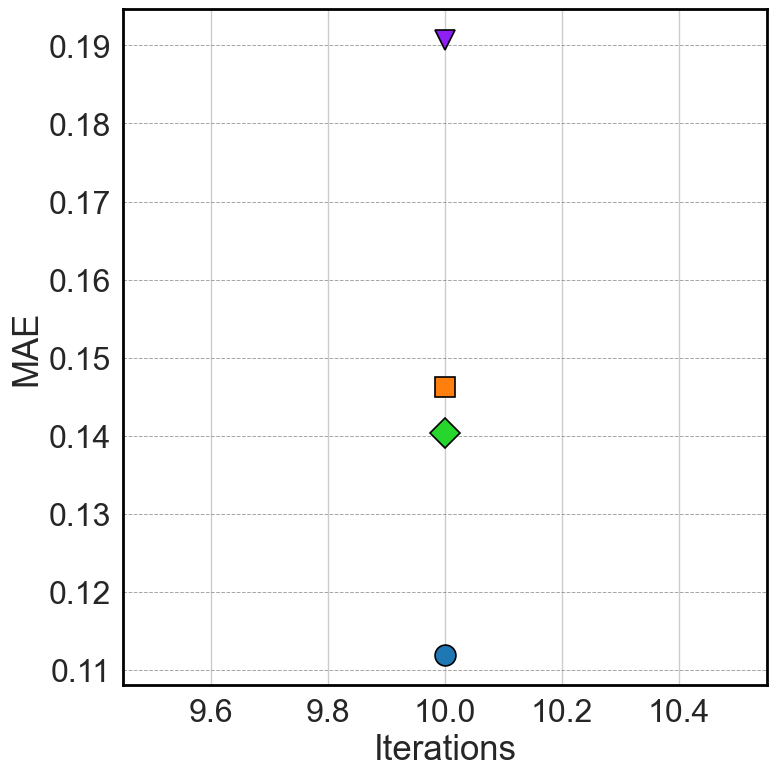

NameError: name 'save_path' is not defined

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# ===== Load CSV results (change path if needed) =====
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_mae_test.csv"
    # e.g., could also be your Energy file if it contains Iteration info
)

# Normalize column names if needed
if "Algorithm" not in df_results.columns and "Method" in df_results.columns:
    df_results = df_results.rename(columns={"Method": "Algorithm"})

# Keep MCAR only if present (optional)
if "MissingType" in df_results.columns:
    df_results = df_results[df_results["MissingType"] == "MCAR"].copy()

# Ensure numeric Iteration
if "Iteration" in df_results.columns:
    df_results["Iteration"] = pd.to_numeric(df_results["Iteration"], errors="coerce")



# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute": {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":      {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "MIWAE":     {"color": "#27d62d", "marker": "D"},   # Green diamond
    "GAIN":      {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S":  {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U":  {"color": "#431271", "marker": "v"},
}

algorithms = df_results["Algorithm"].unique()

# ---- Plot: ECE vs Iteration (one line per algorithm) ----
plt.figure(figsize=(8, 8))
for algo in algorithms:
    # Skip S/U variants if you don't want them
    if algo in {"GAIN-S", "GAIN-U", "MIWAE-U", "MIWAE-S"}:
        continue

    g = df_results[df_results["Algorithm"] == algo].sort_values("Iteration")
    if g.empty:
        continue

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        g["Iteration"], g["MAE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo,
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Iterations", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)

# Legend
#plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
#save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_MAE_vs_Iteration.pdf"
#plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

print("Saved to:", save_path)


## Visualizations

ECE vs Iterations

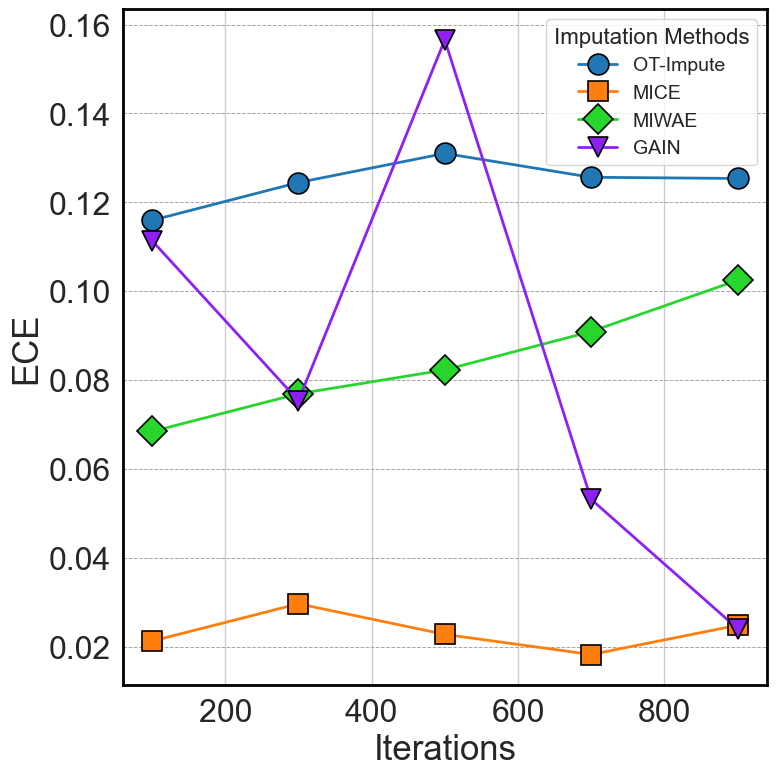

Saved to: C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_ECE_vs_Iteration.pdf


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# ===== Load CSV results (change path if needed) =====
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_ece.csv"
    # e.g., could also be your Energy file if it contains Iteration info
)

# Normalize column names if needed
if "Algorithm" not in df_results.columns and "Method" in df_results.columns:
    df_results = df_results.rename(columns={"Method": "Algorithm"})

# Keep MCAR only if present (optional)
if "MissingType" in df_results.columns:
    df_results = df_results[df_results["MissingType"] == "MCAR"].copy()

# Ensure numeric Iteration
if "Iteration" in df_results.columns:
    df_results["Iteration"] = pd.to_numeric(df_results["Iteration"], errors="coerce")

# --- If ECE isn't present, compute it per (Algorithm, Iteration) from per-point data ---
def compute_ece(true_vals, mean_vals, std_vals):
    std_safe = np.asarray(std_vals) + 1e-6
    cdf_vals = norm.cdf(np.asarray(true_vals), loc=np.asarray(mean_vals), scale=std_safe)
    qs = np.linspace(0, 1, 11)
    props = [(cdf_vals < q).mean() for q in qs]
    return float(np.abs(np.array(props) - qs).mean())

if "ECE" not in df_results.columns:
    required = {"Algorithm", "Iteration", "TrueValue", "ImputedMean", "ImputedStd"}
    if required.issubset(df_results.columns):
        ece_rows = []
        for (algo, itr), g in df_results.groupby(["Algorithm", "Iteration"]):
            ece_rows.append({
                "Algorithm": algo,
                "Iteration": itr,
                "ECE": compute_ece(g["TrueValue"].values, g["ImputedMean"].values, g["ImputedStd"].values),
            })
        df_results = pd.DataFrame(ece_rows)
    else:
        raise ValueError("CSV must contain ECE or per-point columns (TrueValue, ImputedMean, ImputedStd).")

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 16
legend_label_fontsize = 14
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute": {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":      {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "MIWAE":     {"color": "#27d62d", "marker": "D"},   # Green diamond
    "GAIN":      {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S":  {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U":  {"color": "#431271", "marker": "v"},
}

algorithms = df_results["Algorithm"].unique()

# ---- Plot: ECE vs Iteration (one line per algorithm) ----
plt.figure(figsize=(8, 8))
for algo in algorithms:
    # Skip S/U variants if you don't want them
    if algo in {"GAIN-S", "GAIN-U", "MIWAE-U", "MIWAE-S"}:
        continue

    g = df_results[df_results["Algorithm"] == algo].sort_values("Iteration")
    if g.empty:
        continue

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        g["Iteration"], g["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo,
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Iterations", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_ECE_vs_Iteration.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

print("Saved to:", save_path)


MAE VS Iterations

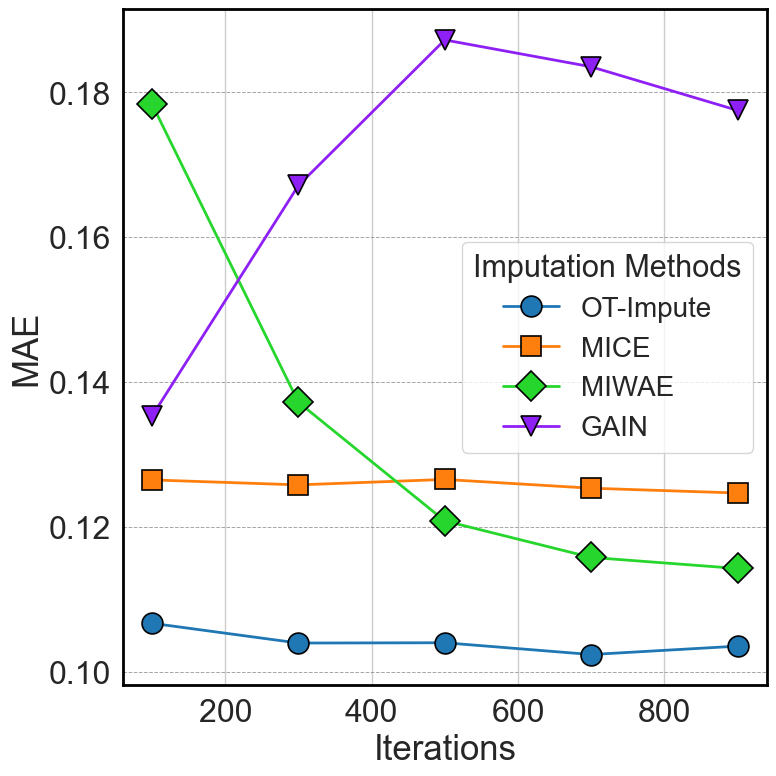

Saved to: C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_MAE_vs_Iteration.pdf


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# ===== Load CSV results (change path if needed) =====
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_mae.csv"
    # e.g., could also be your Energy file if it contains Iteration info
)

# Normalize column names if needed
if "Algorithm" not in df_results.columns and "Method" in df_results.columns:
    df_results = df_results.rename(columns={"Method": "Algorithm"})

# Keep MCAR only if present (optional)
if "MissingType" in df_results.columns:
    df_results = df_results[df_results["MissingType"] == "MCAR"].copy()

# Ensure numeric Iteration
if "Iteration" in df_results.columns:
    df_results["Iteration"] = pd.to_numeric(df_results["Iteration"], errors="coerce")



# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute": {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":      {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "MIWAE":     {"color": "#27d62d", "marker": "D"},   # Green diamond
    "GAIN":      {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S":  {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U":  {"color": "#431271", "marker": "v"},
}

algorithms = df_results["Algorithm"].unique()

# ---- Plot: ECE vs Iteration (one line per algorithm) ----
plt.figure(figsize=(8, 8))
for algo in algorithms:
    # Skip S/U variants if you don't want them
    if algo in {"GAIN-S", "GAIN-U", "MIWAE-U", "MIWAE-S"}:
        continue

    g = df_results[df_results["Algorithm"] == algo].sort_values("Iteration")
    if g.empty:
        continue

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        g["Iteration"], g["MAE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo,
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Iterations", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_MAE_vs_Iteration.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

print("Saved to:", save_path)


time vs iterations

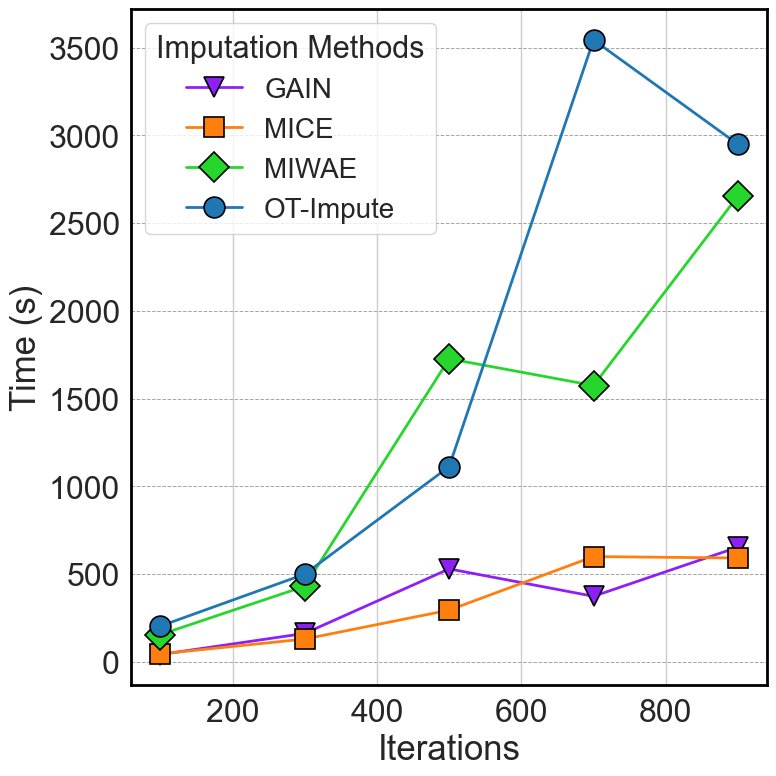

Saved to: C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_Time_vs_Iteration.pdf


In [ ]:

df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_ece.csv"
    # ^ change to your file if needed; any CSV with 'Iteration' and 'Time' works
)

# Normalize column names if needed
if "Algorithm" not in df_results.columns and "Method" in df_results.columns:
    df_results = df_results.rename(columns={"Method": "Algorithm"})

# (Optional) keep MCAR only if present
if "MissingType" in df_results.columns:
    df_results = df_results[df_results["MissingType"] == "MCAR"].copy()

# Ensure numeric
df_results["Iteration"] = pd.to_numeric(df_results["Iteration"], errors="coerce")
df_results["Time"] = pd.to_numeric(df_results["Time"], errors="coerce")
df_results = df_results.dropna(subset=["Iteration", "Time"])

# If duplicates exist for (Algorithm, Iteration), keep the last one (or change to 'mean')
df_results = (
    df_results.sort_values(["Algorithm", "Iteration"])
              .drop_duplicates(subset=["Algorithm", "Iteration"], keep="last")
)

algorithms = df_results["Algorithm"].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute": {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":      {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "MIWAE":     {"color": "#27d62d", "marker": "D"},   # Green diamond
    "GAIN":      {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S":  {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U":  {"color": "#431271", "marker": "v"},
}

# ---- Plot: Time vs Iteration ----
plt.figure(figsize=(8, 8))
ax = plt.gca()

for algo in algorithms:
    # Skip S/U variants if you don't want them (match your previous plot)
    if algo in {"GAIN-S", "GAIN-U", "MIWAE-U", "MIWAE-S"}:
        continue

    g = df_results[df_results["Algorithm"] == algo].sort_values("Iteration")
    if g.empty:
        continue

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    ax.plot(
        g["Iteration"], g["Time"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo,
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
ax.set_xlabel("Iterations", fontsize=x_label_fontsize)
ax.set_ylabel("Time (s)", fontsize=y_label_fontsize)

# Optional: use log scale if times vary a lot
# ax.set_yscale("log")

# Legend
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines & ticks
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_Time_vs_Iteration.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

print("Saved to:", save_path)


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== Load CSV with per-cell rows (has TimeSec, Sample, Algorithm) =====
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_timeVSsamples.csv"
)

# If you saved a compact summary instead, you can load it directly:
# df_results = pd.read_csv(
#     r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_time_summary.csv"
# )

# Normalize column names if needed
if "Algorithm" not in df_results.columns and "Method" in df_results.columns:
    df_results = df_results.rename(columns={"Method": "Algorithm"})

# Keep only needed cols and ensure numeric Sample/Time
keep_cols = {"Algorithm", "Sample", "Time"}
if not keep_cols.issubset(df_results.columns):
    raise ValueError(f"CSV must contain columns: {keep_cols}")
df = df_results[list(keep_cols)].copy()
df["Sample"] = pd.to_numeric(df["Sample"], errors="coerce")
df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
df = df.dropna(subset=["Sample", "Time"])

# Collapse per-cell duplicates → one time per (Algorithm, Sample)
# (You recorded the same TimeSec for all cells of a method/sample, so 'first' is fine.)
df_time = (
    df.sort_values(["Algorithm", "Sample"])
      .drop_duplicates(subset=["Algorithm", "Sample"], keep="first")
)

algorithms = df_time["Algorithm"].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute": {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":      {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "MIWAE":     {"color": "#27d62d", "marker": "D"},   # Green diamond
    "GAIN":      {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S":  {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U":  {"color": "#431271", "marker": "v"},
}

# ---- Plot: Time vs Sample ----
plt.figure(figsize=(8, 8))
ax = plt.gca()

for algo in algorithms:
    g = df_time[df_time["Algorithm"] == algo].sort_values("Sample")
    if g.empty:
        continue

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    ax.plot(
        g["Sample"], g["Time"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo,
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
ax.set_xlabel("Samples", fontsize=x_label_fontsize)
ax.set_ylabel("Time (s)", fontsize=y_label_fontsize)

# Optional: if times vary a lot, use log scale
# ax.set_yscale("log")

# Legend
ax.legend(title="Imputation Methods")

# Borders (black edges)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid & ticks
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_Time_vs_Sample_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

print("Saved to:", save_path)


## MCAR

Calibration curve for all algorithms

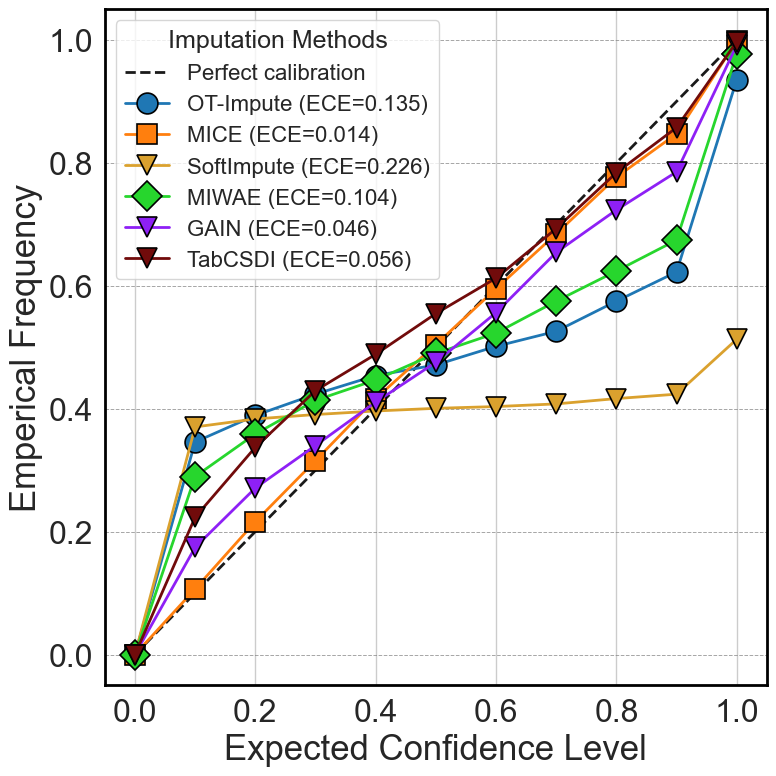

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Missing Rate for all algorithms

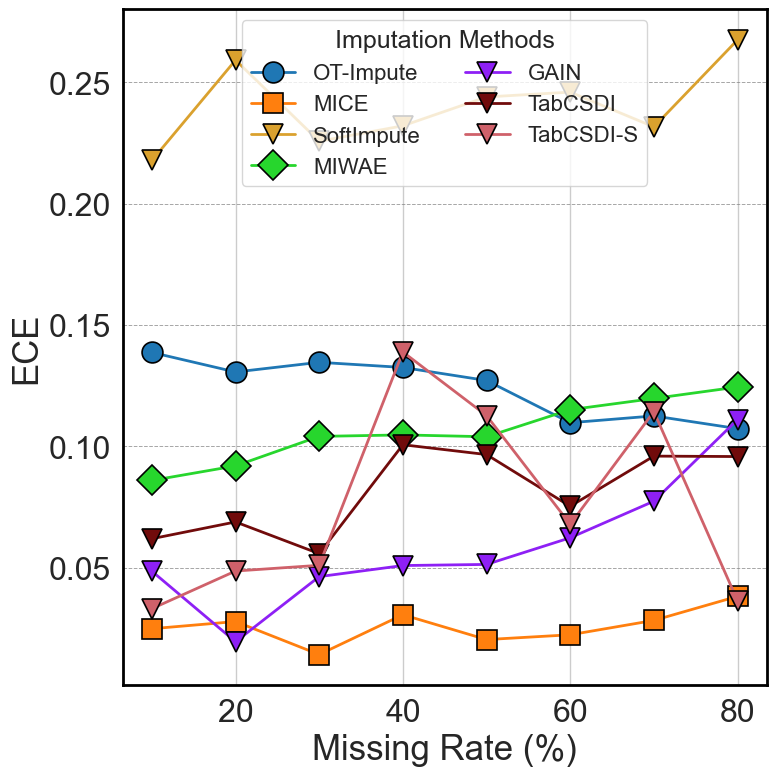

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_results_with_all_missing_values.csv"
)

# Rename algorithms for consistency


algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    if algo == "MIWAE-U" or algo == "MIWAE-S" or algo == "GAIN-U" or algo == "GAIN-S":
        continue

    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(ncol=2,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0.00, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR_ECE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MAE vs MissingRate for all algorithms

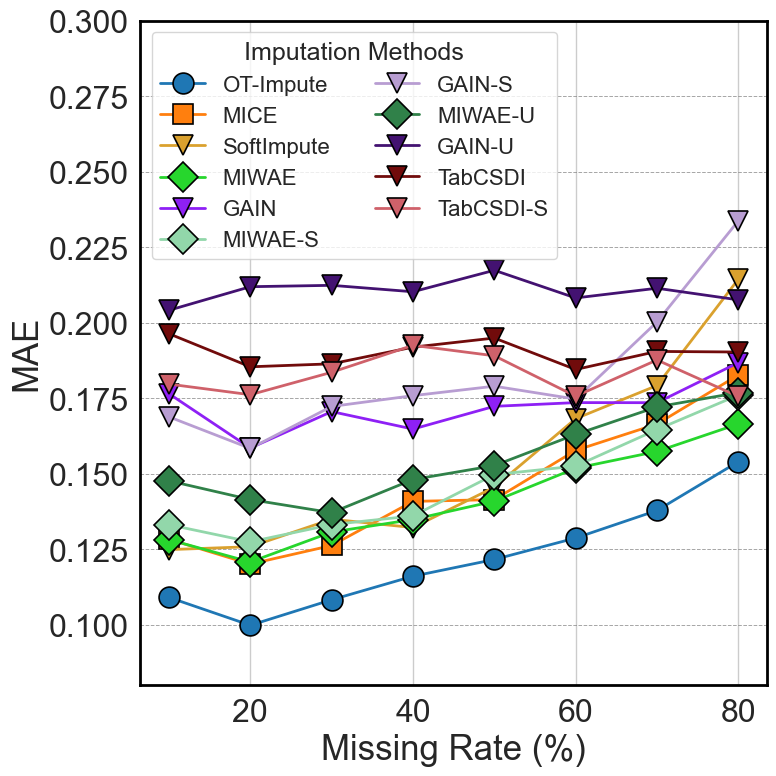

In [ ]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_mae.csv"
)

# Keep the same variable name as before
algorithms = df_mae['Algorithm'].unique()
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_mae[df_mae['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())

    # In case there are multiple rows per (algo, rate), average them (same idea as before)
    mae_values = [df_algo[df_algo['MissingRate'] == mr]['MAE'].mean() for mr in missing_rates]

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, mae_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels (same variables)
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
#plt.title("MAE vs Missing Rate for All Algorithms (MAR)", fontsize=28)

# Legend (kept exactly like your ECE code — commented)
plt.legend(ncol=2,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges) — same as your ECE code
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines — same as your ECE code
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Keep the same y-limit line as in your ECE plot
ax.set_ylim(0.08, 0.30)

# Tick params — same sizes
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MCAR

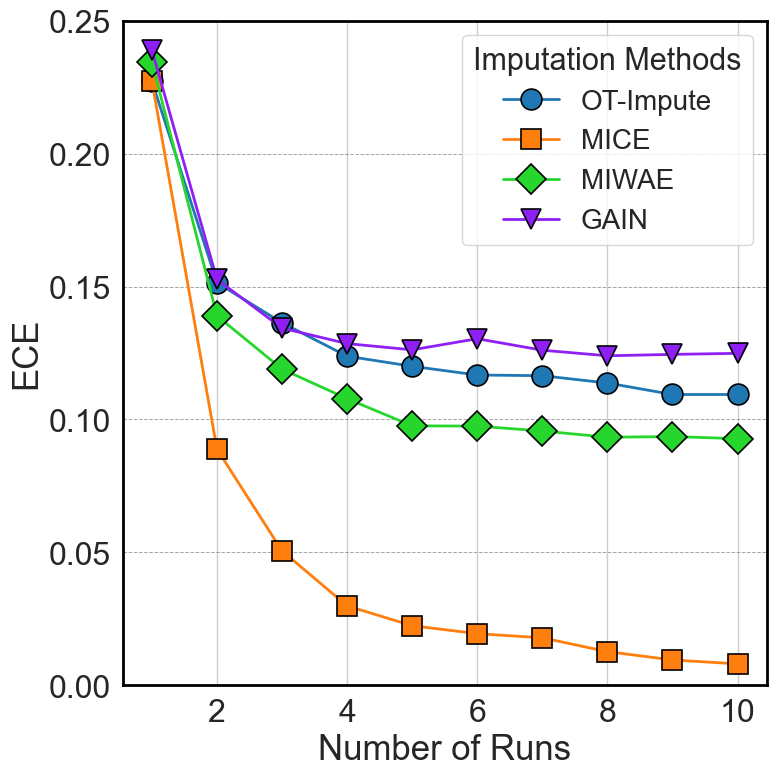

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_results_progressive.csv"
)


missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    if algo=="VAEAC":
        continue

    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Number of Runs", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
plt.legend(title="Imputation Methods",loc='upper right', fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax.set_ylim(0, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_ECE_VS_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MCAR ECE VS Sample 

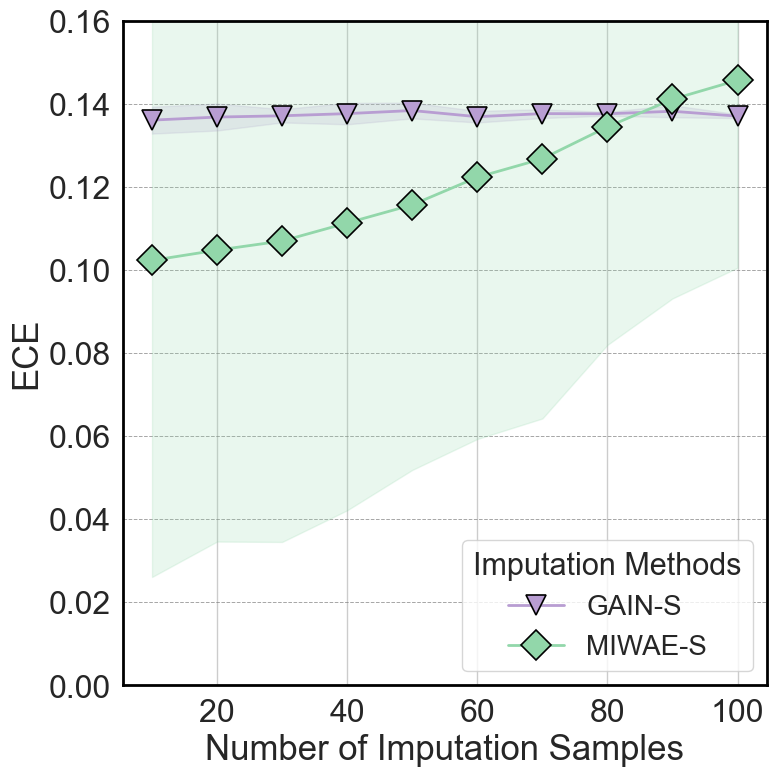

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_results_sample_runs.csv"
)

missing_rate_to_plot = 30
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}
# === Compute ECE per run and sample ===
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for run in df_filtered["run"].unique():
        for sample in sorted(df_filtered["Sample"].unique()):
            sample_df = df_filtered[
                (df_filtered["Algorithm"] == algo) &
                (df_filtered["Sample"] == sample) &
                (df_filtered["run"] == run)
            ]

            true_vals = sample_df['TrueValue'].values
            mean_vals = sample_df['ImputedMean'].values
            std_vals = sample_df['ImputedStd'].values

            if len(true_vals) == 0:
                continue

            quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
            ece = np.abs(np.array(proportions) - quantiles).mean()

            ece_results.append({
                "Algorithm": algo,
                "Sample": sample,
                "Run": run,
                "ECE": ece
            })

ece_df = pd.DataFrame(ece_results)

# === Aggregate across runs (mean + std) ===
ece_summary = ece_df.groupby(["Algorithm", "Sample"])["ECE"].agg(["mean", "std"]).reset_index()

# ---- Plot ECE vs Sample with shading ----
plt.figure(figsize=(8, 8))

for algo in ece_summary["Algorithm"].unique():
    algo_data = ece_summary[ece_summary["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Mean line
    plt.plot(
        algo_data["Sample"], algo_data["mean"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

    # Shaded std
    plt.fill_between(
        algo_data["Sample"],
        algo_data["mean"] - algo_data["std"],
        algo_data["mean"] + algo_data["std"],
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Number of Imputation Samples", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax.set_ylim(0, 0.16)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save figure
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MIWAE Comparission

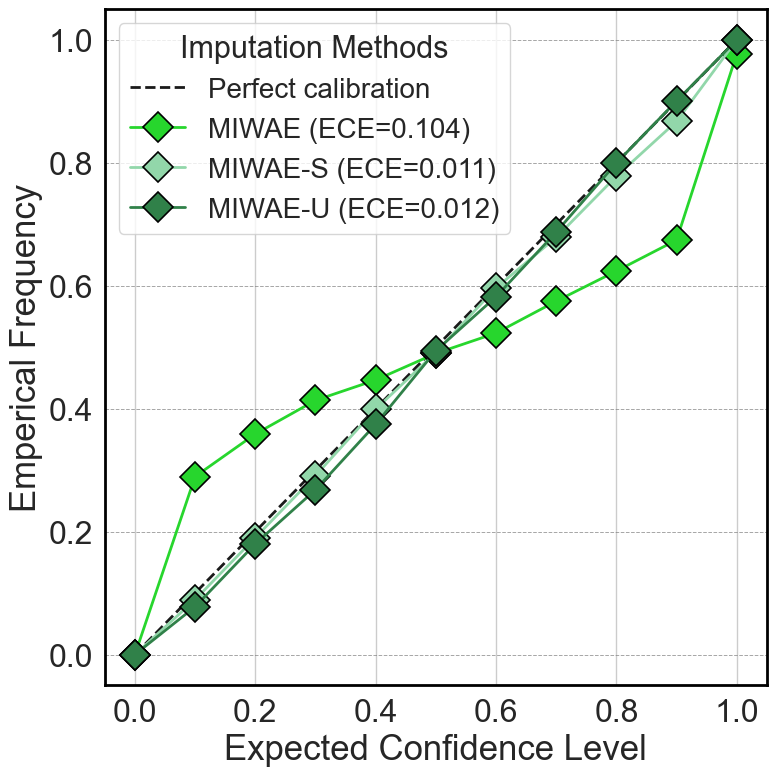

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["MIWAE", "MIWAE-S", "MIWAE-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mcar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



GAIN Comaprission

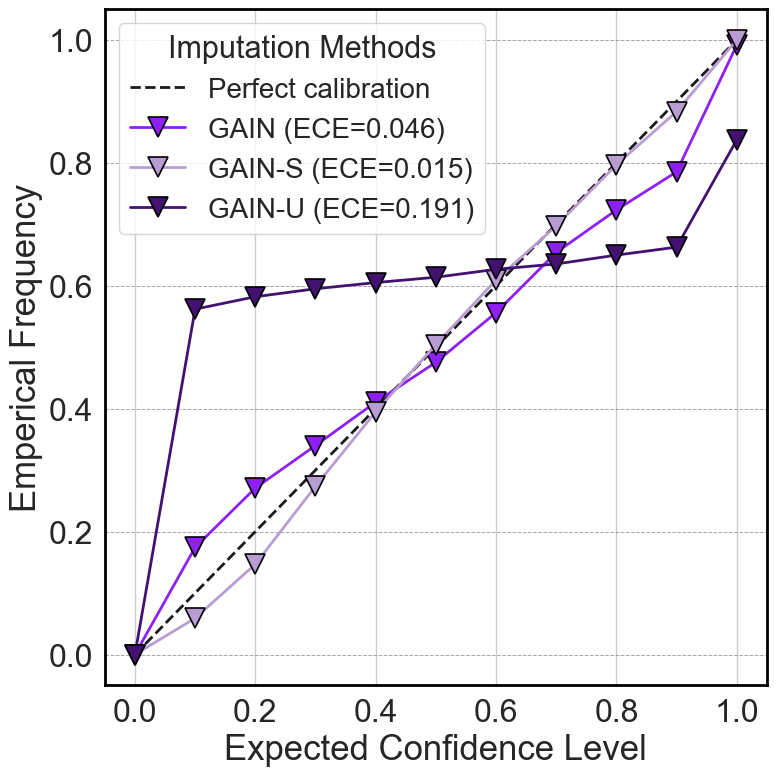

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["GAIN", "GAIN-S", "GAIN-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()


# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mcar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



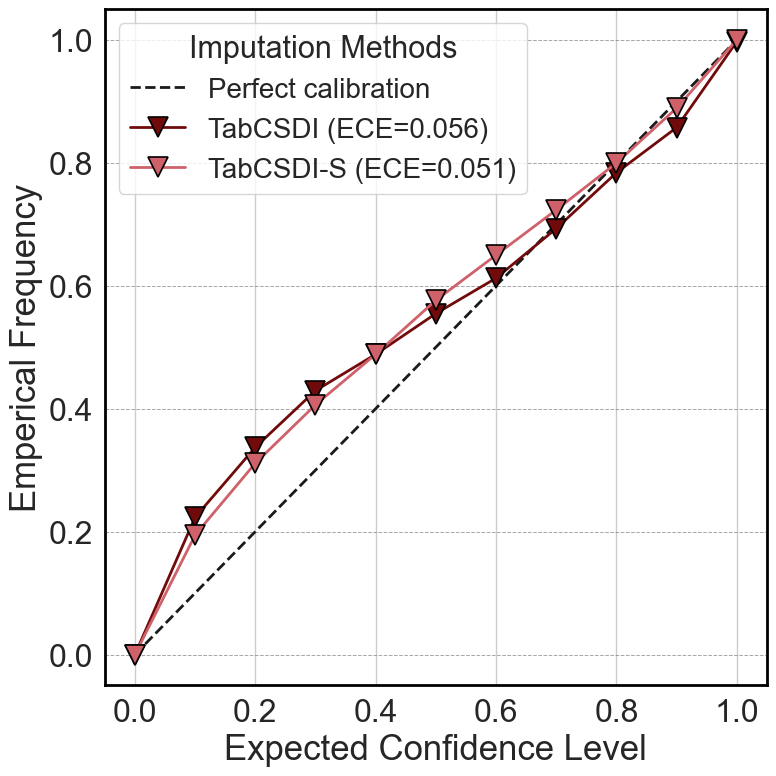

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["TabCSDI", "TabCSDI-S"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mcar_tabcsd_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


## MAR

Calibration curve for all algorithms

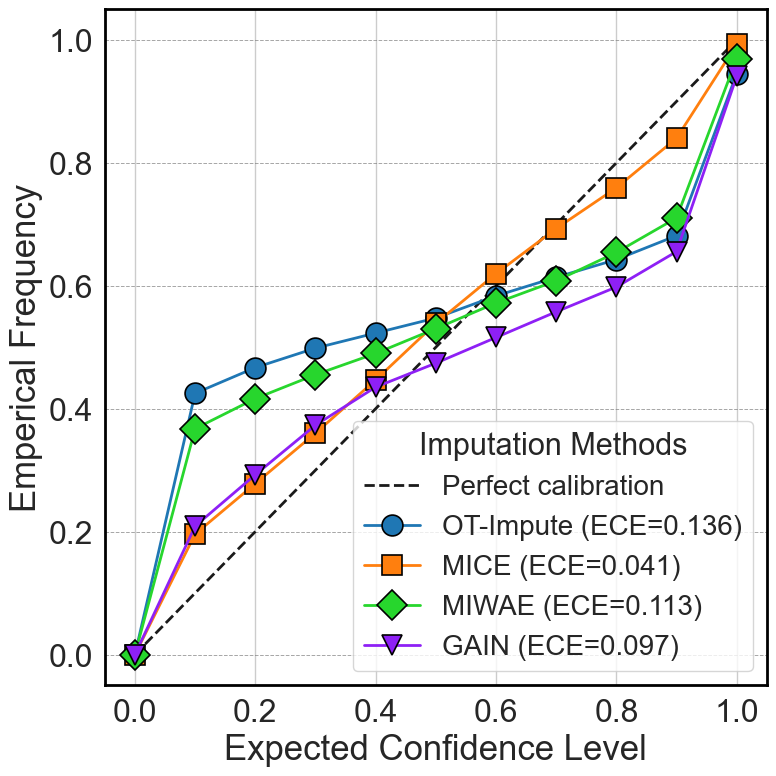

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S":
        continue  # <-- skip VAEAC
       
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Missing Rate for all algorithms

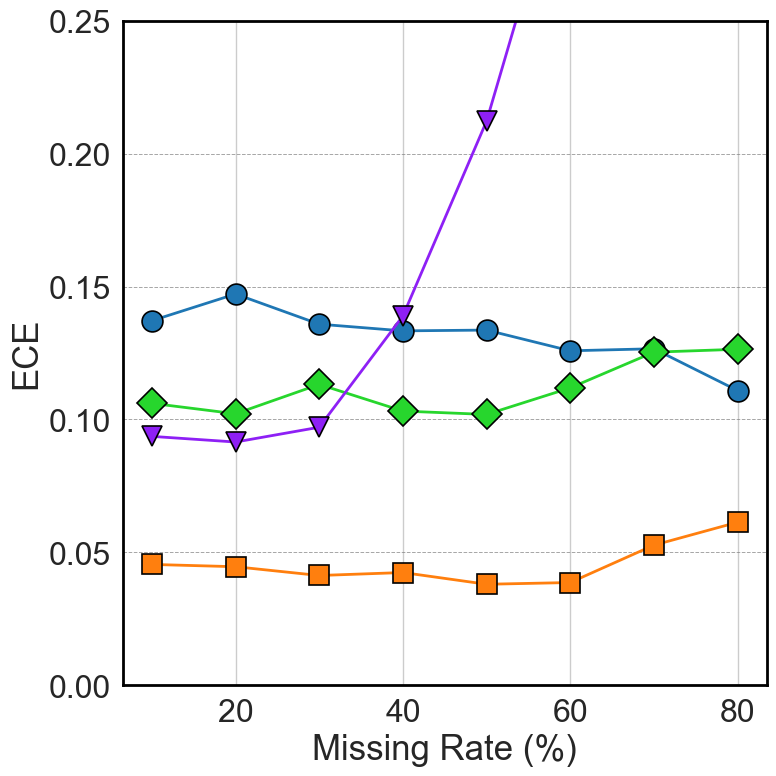

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_results_with_all_missing_values.csv"
)

# Rename algorithms for consistency


algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    if algo == "MIWAE-U" or algo == "MIWAE-S" or algo == "GAIN-U" or algo == "GAIN-S":
        continue

    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
#plt.legend(ncol=2,title="Imputation Methods",loc='upper left', fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax.set_ylim(0, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MAR_ECE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\zhossai3\\Desktop\\Uncertainty\\imputation_Uncertainty\\Output\\Wine_MAR_MAE_vs_MissingRate.pdf'

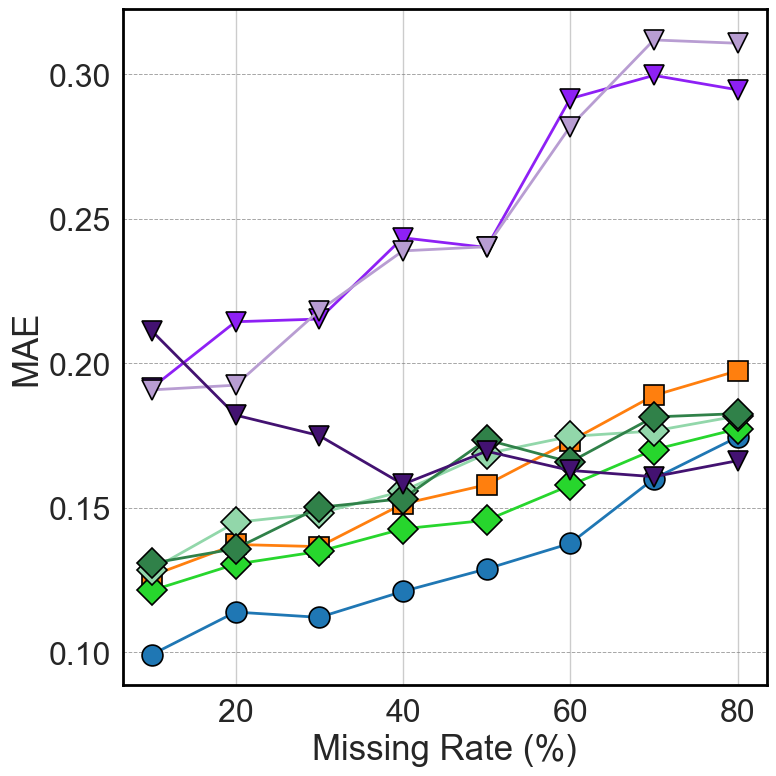

In [ ]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_mae.csv"
)

# Keep the same variable name as before
algorithms = df_mae['Algorithm'].unique()
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_mae[df_mae['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())

    # In case there are multiple rows per (algo, rate), average them (same idea as before)
    mae_values = [df_algo[df_algo['MissingRate'] == mr]['MAE'].mean() for mr in missing_rates]

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, mae_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels (same variables)
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
#plt.title("MAE vs Missing Rate for All Algorithms (MAR)", fontsize=28)

# Legend (kept exactly like your ECE code — commented)
#plt.legend(ncol=2,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges) — same as your ECE code
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines — same as your ECE code
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Keep the same y-limit line as in your ECE plot
#ax.set_ylim(0.08, 0.27)

# Tick params — same sizes
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MAR

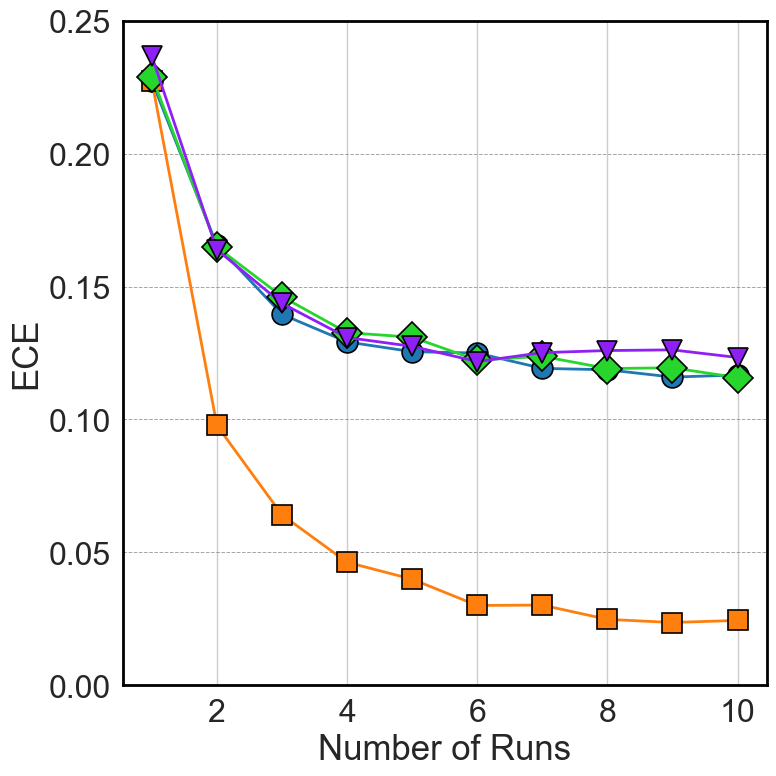

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_results_progressive.csv"
)


missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    if algo=="VAEAC":
        continue

    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Number of Runs", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
#plt.legend(title="Imputation Methods",loc='upper right', fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax.set_ylim(0, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MAR30_ECE_VS_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MAR ECE VS Sample 

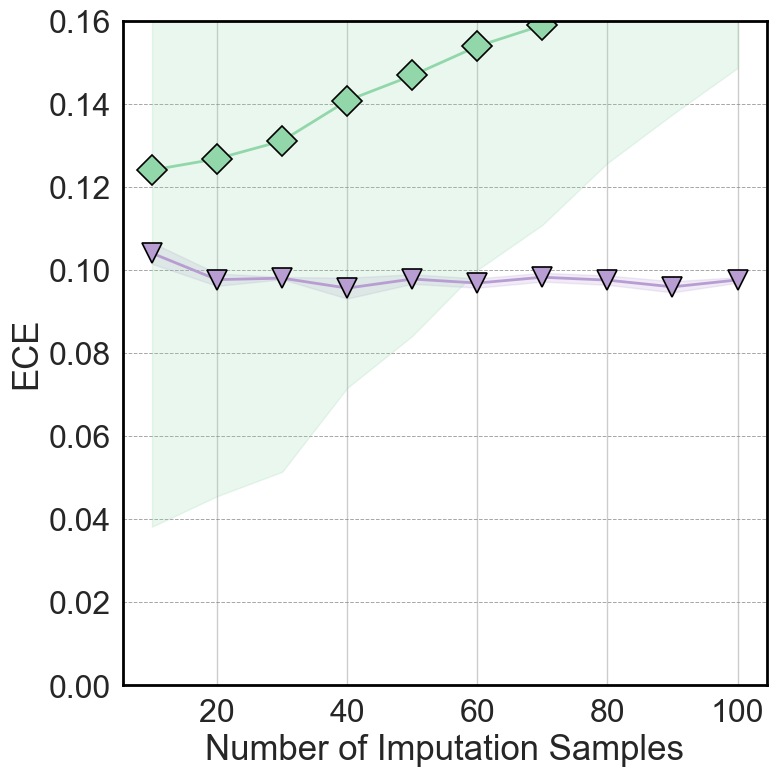

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_results_sample_runs.csv"
)

missing_rate_to_plot = 30
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}
# === Compute ECE per run and sample ===
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for run in df_filtered["run"].unique():
        for sample in sorted(df_filtered["Sample"].unique()):
            sample_df = df_filtered[
                (df_filtered["Algorithm"] == algo) &
                (df_filtered["Sample"] == sample) &
                (df_filtered["run"] == run)
            ]

            true_vals = sample_df['TrueValue'].values
            mean_vals = sample_df['ImputedMean'].values
            std_vals = sample_df['ImputedStd'].values

            if len(true_vals) == 0:
                continue

            quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
            ece = np.abs(np.array(proportions) - quantiles).mean()

            ece_results.append({
                "Algorithm": algo,
                "Sample": sample,
                "Run": run,
                "ECE": ece
            })

ece_df = pd.DataFrame(ece_results)

# === Aggregate across runs (mean + std) ===
ece_summary = ece_df.groupby(["Algorithm", "Sample"])["ECE"].agg(["mean", "std"]).reset_index()

# ---- Plot ECE vs Sample with shading ----
plt.figure(figsize=(8, 8))

for algo in ece_summary["Algorithm"].unique():
    algo_data = ece_summary[ece_summary["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Mean line
    plt.plot(
        algo_data["Sample"], algo_data["mean"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

    # Shaded std
    plt.fill_between(
        algo_data["Sample"],
        algo_data["mean"] - algo_data["std"],
        algo_data["mean"] + algo_data["std"],
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Number of Imputation Samples", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
#plt.legend(title="Imputation Methods",loc="center",bbox_to_anchor=(0.7, 0.13), fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)
ax.set_ylim(0, 0.16)
plt.tight_layout()

# Save figure
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MIWAE Comparission

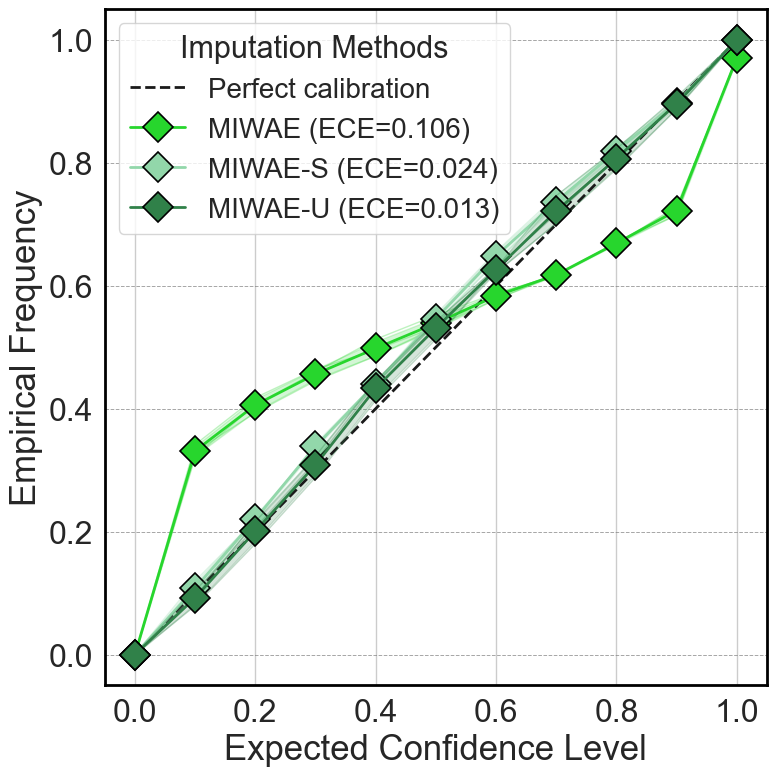

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_miwae_comparision.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
   
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    n_runs = 3
    n_points = len(df_algo) // n_runs
    all_props = []

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Plot each individual run (faint lines)
    for i in range(n_runs):
        df_run = df_algo.iloc[i*n_points:(i+1)*n_points]
        true_vals = df_run['TrueValue'].values
        mean_vals = df_run['ImputedMean'].values
        std_vals = df_run['ImputedStd'].values

        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        all_props.append(proportions)

        # Faint line for individual run
        plt.plot(
            quantiles, proportions,
            color=style["color"], alpha=0.3, linewidth=1
        )

    all_props = np.array(all_props)
    mean_props = all_props.mean(axis=0)
    std_props = all_props.std(axis=0)
    ece = np.abs(mean_props - quantiles).mean()  # ECE using mean

    # Plot mean curve (solid with marker)
    plt.plot(
        quantiles, mean_props,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

    # Shaded area for variability
    plt.fill_between(
        quantiles, mean_props - std_props, mean_props + std_props,
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Empirical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods", 
           fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



GAIN Comaprission

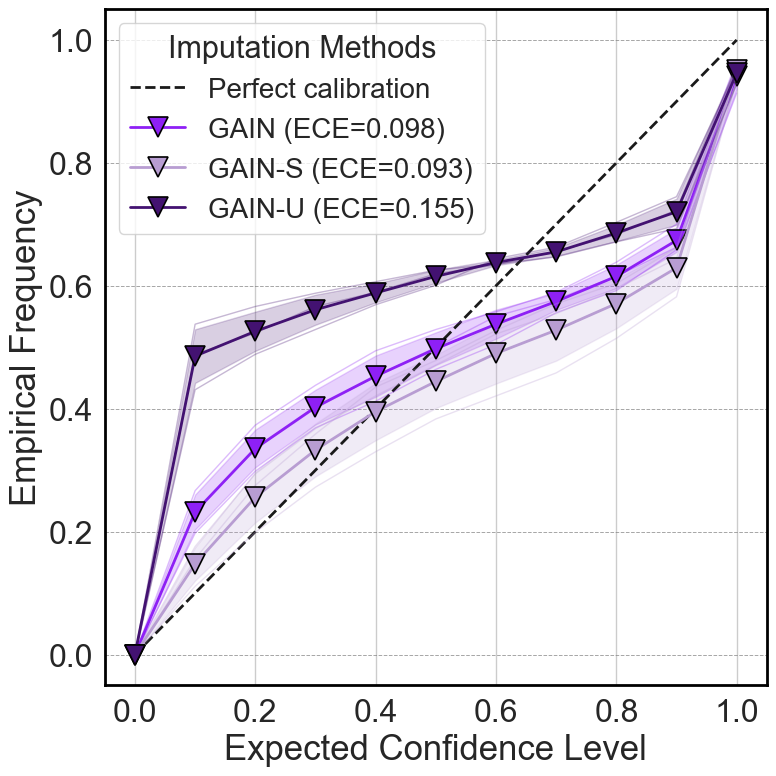

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_gain_comparision.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:

    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    n_runs = 3
    n_points = len(df_algo) // n_runs
    all_props = []

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Plot each individual run (faint lines)
    for i in range(n_runs):
        df_run = df_algo.iloc[i*n_points:(i+1)*n_points]
        true_vals = df_run['TrueValue'].values
        mean_vals = df_run['ImputedMean'].values
        std_vals = df_run['ImputedStd'].values

        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        all_props.append(proportions)

        # Faint line for individual run
        plt.plot(
            quantiles, proportions,
            color=style["color"], alpha=0.3, linewidth=1
        )

    all_props = np.array(all_props)
    mean_props = all_props.mean(axis=0)
    std_props = all_props.std(axis=0)
    ece = np.abs(mean_props - quantiles).mean()  # ECE using mean

    # Plot mean curve (solid with marker)
    plt.plot(
        quantiles, mean_props,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

    # Shaded area for variability
    plt.fill_between(
        quantiles, mean_props - std_props, mean_props + std_props,
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Empirical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods", 
           fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



## MNAR

Calibration curve for all algorithms

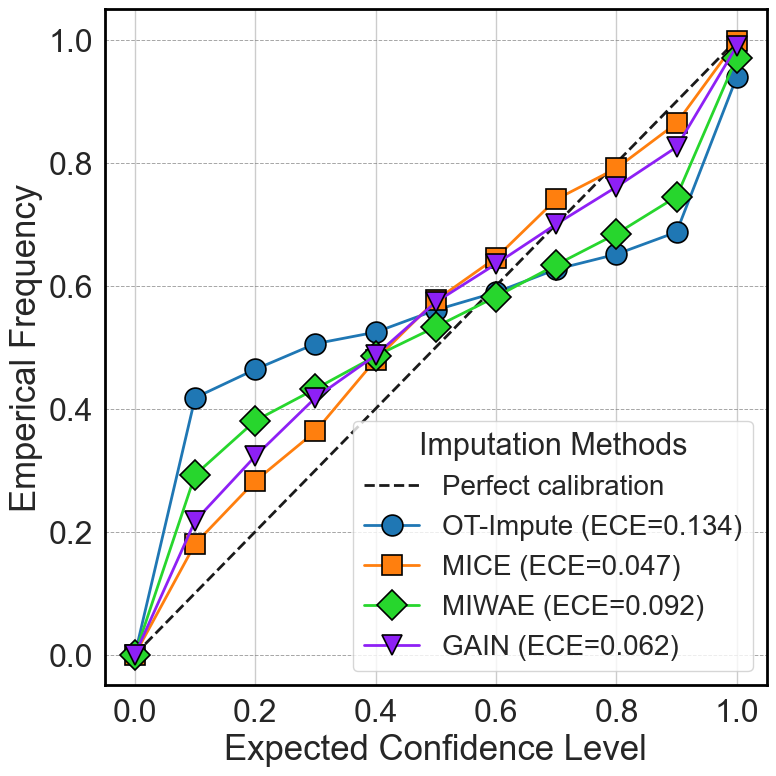

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S":
        continue

    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MNAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Missing Rate for all algorithms

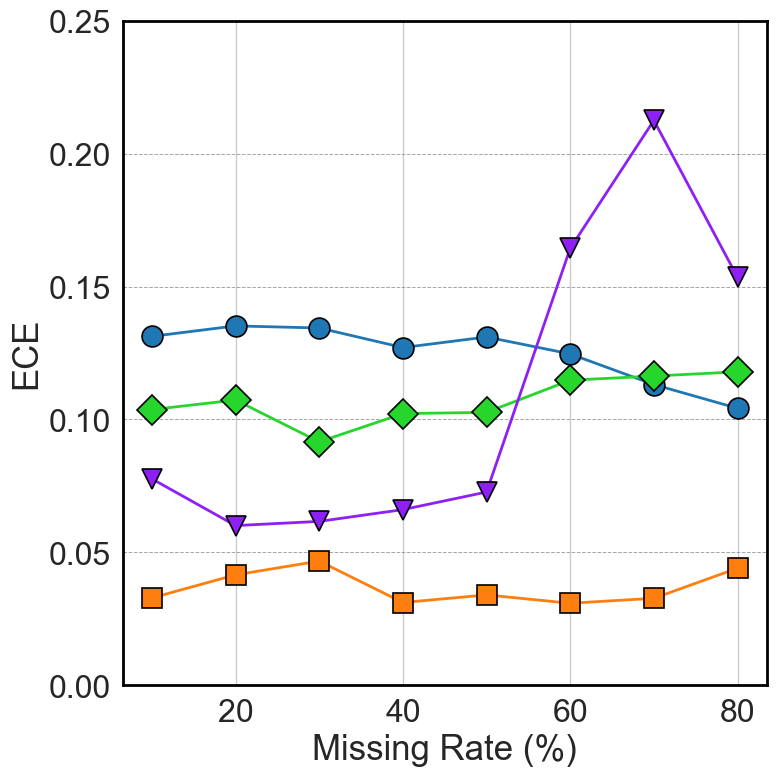

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_results_with_all_missing_values.csv"
)

# Rename algorithms for consistency


algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    if algo == "MIWAE-U" or algo == "MIWAE-S" or algo == "GAIN-U" or algo == "GAIN-S":
        continue

    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
#plt.legend(ncol=2,title="Imputation Methods",loc='upper left', fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax.set_ylim(0, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MNAR_ECE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


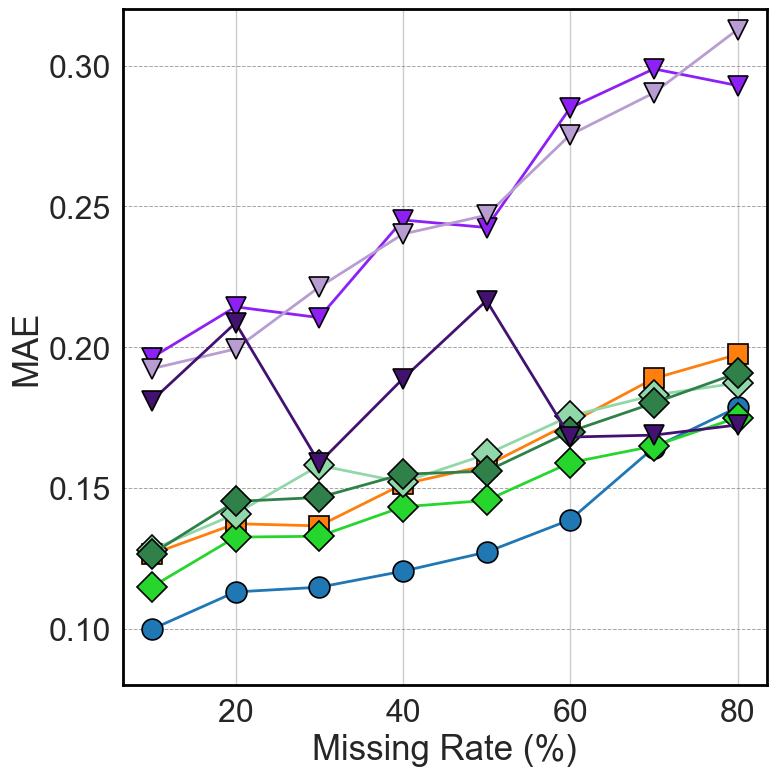

In [ ]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_mae.csv"
)

# Keep the same variable name as before
algorithms = df_mae['Algorithm'].unique()
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 16
legend_label_fontsize = 14
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_mae[df_mae['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())

    # In case there are multiple rows per (algo, rate), average them (same idea as before)
    mae_values = [df_algo[df_algo['MissingRate'] == mr]['MAE'].mean() for mr in missing_rates]

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, mae_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels (same variables)
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
#plt.title("MAE vs Missing Rate for All Algorithms (MAR)", fontsize=28)

# Legend (kept exactly like your ECE code — commented)
#plt.legend(ncol=2,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges) — same as your ECE code
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines — same as your ECE code
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Keep the same y-limit line as in your ECE plot
ax.set_ylim(0.08, 0.32)

# Tick params — same sizes
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MNAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MNAR

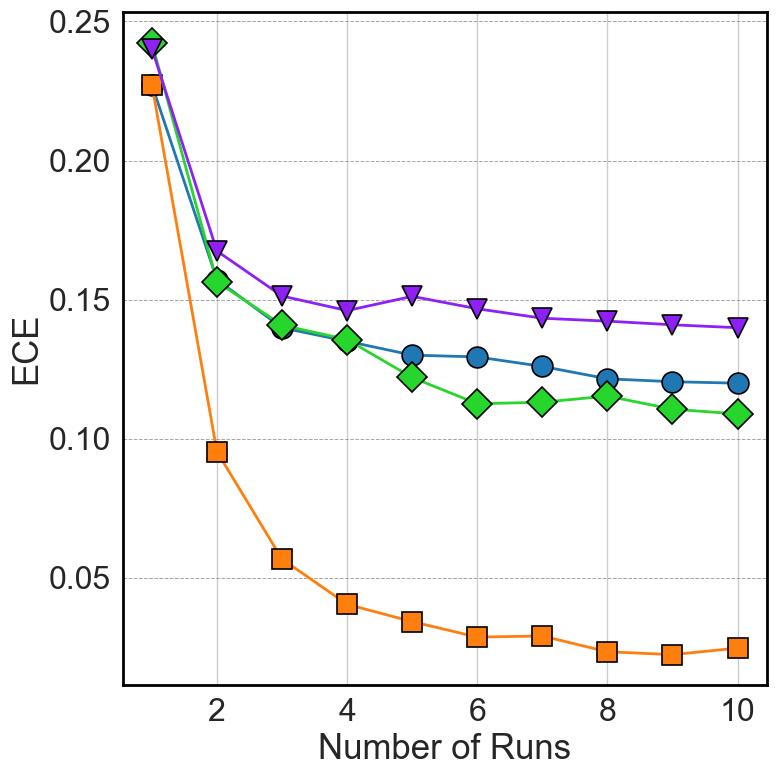

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_results_progressive.csv"
)


missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    if algo=="VAEAC":
        continue

    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Number of Runs", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
#plt.legend(title="Imputation Methods",loc='upper right', fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MNAR30_ECE_VS_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MNAR ECE VS Sample 

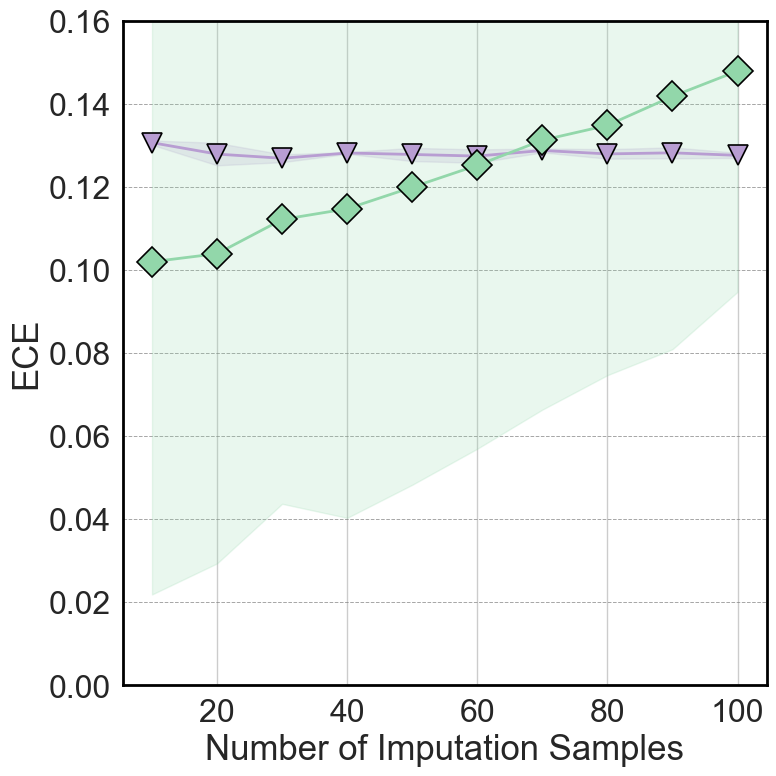

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_results_sample_runs.csv"
)

missing_rate_to_plot = 30
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}
# === Compute ECE per run and sample ===
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for run in df_filtered["run"].unique():
        for sample in sorted(df_filtered["Sample"].unique()):
            sample_df = df_filtered[
                (df_filtered["Algorithm"] == algo) &
                (df_filtered["Sample"] == sample) &
                (df_filtered["run"] == run)
            ]

            true_vals = sample_df['TrueValue'].values
            mean_vals = sample_df['ImputedMean'].values
            std_vals = sample_df['ImputedStd'].values

            if len(true_vals) == 0:
                continue

            quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
            ece = np.abs(np.array(proportions) - quantiles).mean()

            ece_results.append({
                "Algorithm": algo,
                "Sample": sample,
                "Run": run,
                "ECE": ece
            })

ece_df = pd.DataFrame(ece_results)

# === Aggregate across runs (mean + std) ===
ece_summary = ece_df.groupby(["Algorithm", "Sample"])["ECE"].agg(["mean", "std"]).reset_index()

# ---- Plot ECE vs Sample with shading ----
plt.figure(figsize=(8, 8))

for algo in ece_summary["Algorithm"].unique():
    algo_data = ece_summary[ece_summary["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Mean line
    plt.plot(
        algo_data["Sample"], algo_data["mean"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

    # Shaded std
    plt.fill_between(
        algo_data["Sample"],
        algo_data["mean"] - algo_data["std"],
        algo_data["mean"] + algo_data["std"],
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Number of Imputation Samples", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
#plt.legend(title="Imputation Methods",loc="center",bbox_to_anchor=(0.7, 0.13), fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax.set_ylim(0, 0.16)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save figure
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MNAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MIWAE Comparission

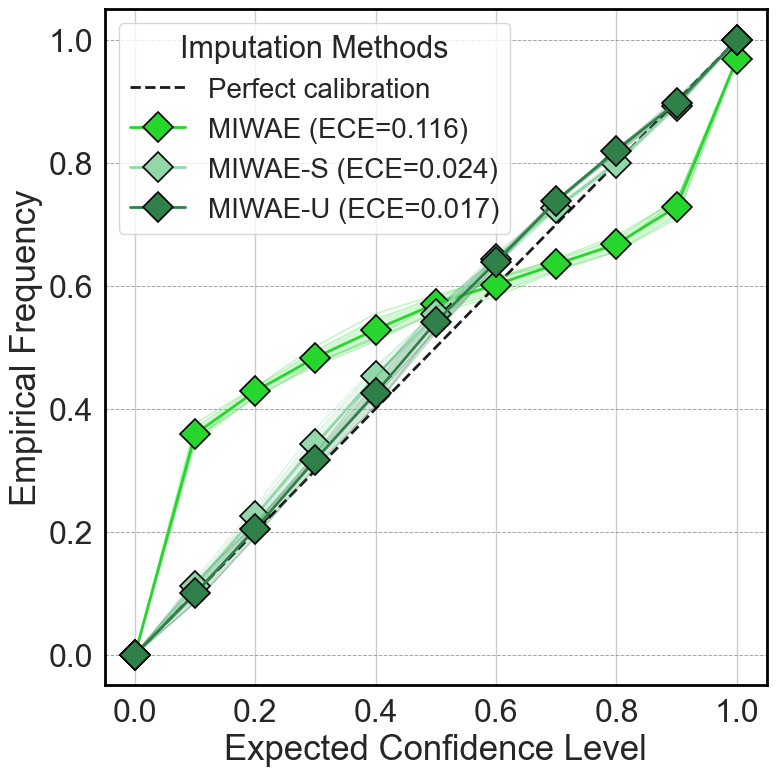

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_miwae_comparision.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "VAEAC":
        continue

    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    n_runs = 3
    n_points = len(df_algo) // n_runs
    all_props = []

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Plot each individual run (faint lines)
    for i in range(n_runs):
        df_run = df_algo.iloc[i*n_points:(i+1)*n_points]
        true_vals = df_run['TrueValue'].values
        mean_vals = df_run['ImputedMean'].values
        std_vals = df_run['ImputedStd'].values

        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        all_props.append(proportions)

        # Faint line for individual run
        plt.plot(
            quantiles, proportions,
            color=style["color"], alpha=0.3, linewidth=1
        )

    all_props = np.array(all_props)
    mean_props = all_props.mean(axis=0)
    std_props = all_props.std(axis=0)
    ece = np.abs(mean_props - quantiles).mean()  # ECE using mean

    # Plot mean curve (solid with marker)
    plt.plot(
        quantiles, mean_props,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

    # Shaded area for variability
    plt.fill_between(
        quantiles, mean_props - std_props, mean_props + std_props,
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Empirical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods", 
           fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mnar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



GAIN Comaprission

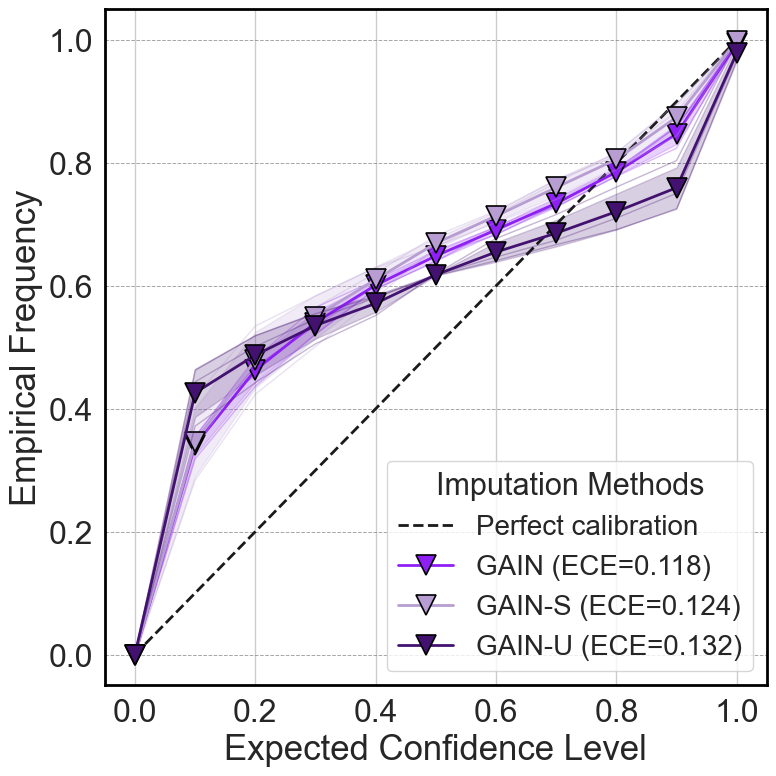

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_gain_comparision.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:

    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    n_runs = 3
    n_points = len(df_algo) // n_runs
    all_props = []

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Plot each individual run (faint lines)
    for i in range(n_runs):
        df_run = df_algo.iloc[i*n_points:(i+1)*n_points]
        true_vals = df_run['TrueValue'].values
        mean_vals = df_run['ImputedMean'].values
        std_vals = df_run['ImputedStd'].values

        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        all_props.append(proportions)

        # Faint line for individual run
        plt.plot(
            quantiles, proportions,
            color=style["color"], alpha=0.3, linewidth=1
        )

    all_props = np.array(all_props)
    mean_props = all_props.mean(axis=0)
    std_props = all_props.std(axis=0)
    ece = np.abs(mean_props - quantiles).mean()  # ECE using mean

    # Plot mean curve (solid with marker)
    plt.plot(
        quantiles, mean_props,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

    # Shaded area for variability
    plt.fill_between(
        quantiles, mean_props - std_props, mean_props + std_props,
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Empirical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods", 
           fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mnar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



In [2]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from Inject_Missing_Values import *
from imputers import *
from imputers_updated import *
from Utils import *
from Gain import *
from MIWAE import *
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time


In [4]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)
import torch.nn as nn

In [5]:
data = fetch_openml(name="wine", version=2, as_frame=True)
X_full = data.data.copy()

In [6]:
print(X_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malic_acid                    178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  OD280/OD315_of_diluted_wines  178 non-null    float64
 12  Proline                       178 non-null    int64  
dtypes: fl

In [7]:
scaler = MinMaxScaler() #data [0,1] #giving better result
X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

#scaler = StandardScaler()
#X_full =  pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

In [8]:
GroundTruth = X_full.copy()
X = X_full.copy()
print(GroundTruth)

      Alcohol  Malic_acid       Ash  Alcalinity_of_ash  Magnesium  \
0    0.842105    0.191700  0.572193           0.257732   0.619565   
1    0.571053    0.205534  0.417112           0.030928   0.326087   
2    0.560526    0.320158  0.700535           0.412371   0.336957   
3    0.878947    0.239130  0.609626           0.319588   0.467391   
4    0.581579    0.365613  0.807487           0.536082   0.521739   
..        ...         ...       ...                ...        ...   
173  0.705263    0.970356  0.582888           0.510309   0.271739   
174  0.623684    0.626482  0.598930           0.639175   0.347826   
175  0.589474    0.699605  0.481283           0.484536   0.543478   
176  0.563158    0.365613  0.540107           0.484536   0.543478   
177  0.815789    0.664032  0.737968           0.716495   0.282609   

     Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
0         0.627586    0.573840              0.283019         0.593060   
1         0.575862    0.5

Converting GroundTruth to tensor

In [9]:
GroundTruth_tensor = torch.tensor(GroundTruth.values, dtype=torch.double)

In [10]:
GroundTruth.nunique()

Alcohol                         126
Malic_acid                      133
Ash                              79
Alcalinity_of_ash                63
Magnesium                        53
Total_phenols                    97
Flavanoids                      132
Nonflavanoid_phenols             39
Proanthocyanins                 101
Color_intensity                 132
Hue                              78
OD280/OD315_of_diluted_wines    122
Proline                         121
dtype: int64

In [11]:
print("Alcohol",GroundTruth['Alcohol'].unique())
print("Malic_acid",GroundTruth['Malic_acid'].unique())
print("Ash",GroundTruth['Ash'].unique())
print("Alcalinity_of_ash",GroundTruth['Alcalinity_of_ash'].unique())
print("Magnesium",GroundTruth["Magnesium"].unique())
print("Total_phenols",GroundTruth['Total_phenols'].unique())
print("Flavanoids",GroundTruth['Flavanoids'].unique())
print("Nonflavanoid_phenols",GroundTruth['Nonflavanoid_phenols'].unique())
print("Proanthocyanins",GroundTruth['Proanthocyanins'].unique())
print("Color_intensity",GroundTruth['Color_intensity'].unique())
print("Hue",GroundTruth['Hue'].unique())
print("OD280/OD315_of_diluted_wines",GroundTruth['OD280/OD315_of_diluted_wines'].unique())
print("Proline",GroundTruth['Proline'].unique())

Alcohol [0.84210526 0.57105263 0.56052632 0.87894737 0.58157895 0.83421053
 0.88421053 0.79736842 1.         0.74473684 0.80789474 0.81315789
 0.71578947 0.97894737 0.88157895 0.68421053 0.86052632 0.73684211
 0.83157895 0.68684211 0.5        0.70526316 0.47894737 0.65
 0.53157895 0.62105263 0.59736842 0.74736842 0.78684211 0.71052632
 0.67105263 0.69736842 0.71842105 0.65263158 0.64473684 0.59210526
 0.53684211 0.83947368 0.66578947 0.62631579 0.75       0.83684211
 0.75526316 0.76578947 0.73421053 0.72105263 0.71315789 0.59473684
 0.70789474 0.35263158 0.34210526 0.42368421 0.69473684 0.3
 0.54736842 0.60789474 0.31052632 0.33157895 0.64736842 0.51578947
 0.24473684 0.16578947 0.52631579 0.21315789 0.43947368 0.25526316
 0.44473684 0.27631579 0.43157895 0.29736842 0.16315789 0.16052632
 0.43684211 0.15526316 0.37894737 0.20526316 0.41315789 0.34473684
 0.20789474 0.38947368 0.36578947 0.32105263 0.31315789 0.15263158
 0.11315789 0.39210526 0.19210526 0.1        0.         0.45789474


Dependecies for MAR & MNAR

In [12]:
mean_alcohol = GroundTruth["Alcohol"].mean()
median_malic = GroundTruth["Malic_acid"].median()
mean_ash = GroundTruth["Ash"].mean()
median_alcalinity = GroundTruth["Alcalinity_of_ash"].median()
mean_magnesium = GroundTruth["Magnesium"].mean()
median_phenols = GroundTruth["Total_phenols"].median()
mean_flavanoids = GroundTruth["Flavanoids"].mean()
median_nonflavanoid = GroundTruth["Nonflavanoid_phenols"].median()
mean_proanthocyanins = GroundTruth["Proanthocyanins"].mean()
median_color = GroundTruth["Color_intensity"].median()
mean_hue = GroundTruth["Hue"].mean()
median_od280 = GroundTruth["OD280/OD315_of_diluted_wines"].median()
mean_proline = GroundTruth["Proline"].mean()


dependencies_mar = {
    "Malic_acid": {
        "influencers": ["Alcohol"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] > mean_alcohol else 0.1
    },
    "Ash": {
        "influencers": ["Malic_acid"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] < median_malic else 0.1
    },
    "Alcalinity_of_ash": {
        "influencers": ["Ash"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Ash"] > mean_ash else 0.1
    },
    "Magnesium": {
        "influencers": ["Total_phenols"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Total_phenols"] < median_phenols else 0.1
    },
    "Total_phenols": {
        "influencers": ["Color_intensity"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] > median_color else 0.1
    },
    "Flavanoids": {
        "influencers": ["Malic_acid"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] < median_malic else 0.1
    },
    "Nonflavanoid_phenols": {
        "influencers": ["Flavanoids"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Flavanoids"] > mean_flavanoids else 0.1
    },
    "Proanthocyanins": {
        "influencers": ["Nonflavanoid_phenols"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Nonflavanoid_phenols"] < median_nonflavanoid else 0.1
    },
    "Color_intensity": {
        "influencers": ["Alcohol"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] > mean_alcohol else 0.1
    },
    "Hue": {
        "influencers": ["Color_intensity"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] > median_color else 0.1
    },
    "OD280/OD315_of_diluted_wines": {
        "influencers": ["Hue"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Hue"] < median_color else 0.1
    },
    "Proline": {
        "influencers": ["OD280/OD315_of_diluted_wines"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["OD280/OD315_of_diluted_wines"] > median_od280 else 0.1
    },
    "Alcohol": {
        "influencers": ["Proline"],  # Adding this as MAR (if you're okay with it having missingness)
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proline"] > mean_proline else 0.1
    }
}



In [13]:
mean_alcohol = GroundTruth["Alcohol"].mean()
median_malic = GroundTruth["Malic_acid"].median()
mean_ash = GroundTruth["Ash"].mean()
median_alcalinity = GroundTruth["Alcalinity_of_ash"].median()
mean_magnesium = GroundTruth["Magnesium"].mean()
median_phenols = GroundTruth["Total_phenols"].median()
median_flav = GroundTruth["Flavanoids"].median()
median_nonflav = GroundTruth["Nonflavanoid_phenols"].median()
mean_proanthocyanins = GroundTruth["Proanthocyanins"].mean()
median_color = GroundTruth["Color_intensity"].median()
mean_hue = GroundTruth["Hue"].mean()
median_od280 = GroundTruth["OD280/OD315_of_diluted_wines"].median()
mean_proline = GroundTruth["Proline"].mean()

dependencies_mnar = {
    "Alcohol": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] < mean_alcohol else 0.1
    },
    "Malic_acid": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] == median_malic else 0.1
    },
    "Ash": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Ash"] >= mean_ash else 0.1
    },
    "Alcalinity_of_ash": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcalinity_of_ash"] <= median_alcalinity else 0.1
    },
    "Magnesium": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Magnesium"] >= mean_magnesium else 0.1
    },
    "Total_phenols": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Total_phenols"] <= median_phenols else 0.1
    },
    "Flavanoids": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Flavanoids"] == median_flav else 0.1
    },
    "Nonflavanoid_phenols": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Nonflavanoid_phenols"] <= median_nonflav else 0.1
    },
    "Proanthocyanins": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proanthocyanins"] < mean_proanthocyanins else 0.1
    },
    "Color_intensity": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] <= median_color else 0.1
    },
    "Hue": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Hue"] >= mean_hue else 0.1
    },
    "OD280/OD315_of_diluted_wines": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["OD280/OD315_of_diluted_wines"] >= median_od280 else 0.1
    },
    "Proline": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proline"] <= mean_proline else 0.1
    }
}


In [14]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)


# Create nested results dictionary
results_mnar = []
result_mae = []


for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    runs = 4
    #missing mask
    missing_mask = miss_mnar.isna()

 


    #GAIN
    t_method_start = time.perf_counter()
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=5000, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
        #print(imputed_std_vae)

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "GAIN",
    "MissingRate": missing_rate,
    "MAE": mae_gain  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    
   

    #GAIN
    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=5000, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-S",
    "MissingRate": missing_rate,
    "MAE": mae_gains  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

   

    print("GAIN-U")
    t_method_start = time.perf_counter()
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=5000, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-U",
    "MissingRate": missing_rate,
    "MAE": mae_gainu  # This is the single number stored once
})
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })


            




30
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
GAIN-S
GAIN-U


In [15]:
print(result_mae)

[{'Algorithm': 'GAIN', 'MissingRate': 30, 'MAE': np.float64(0.2024533951337067)}, {'Algorithm': 'GAIN-S', 'MissingRate': 30, 'MAE': np.float64(0.20423199407281553)}, {'Algorithm': 'GAIN-U', 'MissingRate': 30, 'MAE': np.float64(0.21512930919895548)}]


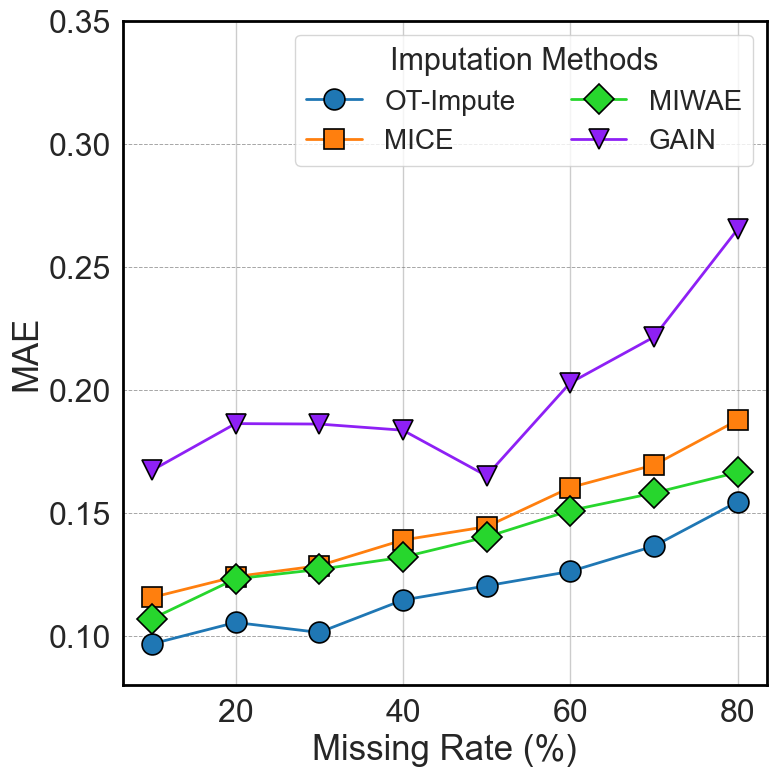

In [21]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_mae.csv"
)

# Keep the same variable name as before
algorithms = df_mae['Algorithm'].unique()
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

plt.figure(figsize=(8, 8))

for algo in algorithms:
    if algo == "MIWAE-U" or algo == "MIWAE-S" or algo == "GAIN-U" or algo == "GAIN-S":
        continue
    df_algo = df_mae[df_mae['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())

    # In case there are multiple rows per (algo, rate), average them (same idea as before)
    mae_values = [df_algo[df_algo['MissingRate'] == mr]['MAE'].mean() for mr in missing_rates]

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, mae_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels (same variables)
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
#plt.title("MAE vs Missing Rate for All Algorithms (MAR)", fontsize=28)

# Legend (kept exactly like your ECE code — commented)
plt.legend(ncol=2,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges) — same as your ECE code
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines — same as your ECE code
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Keep the same y-limit line as in your ECE plot
ax.set_ylim(0.08, 0.35)

# Tick params — same sizes
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


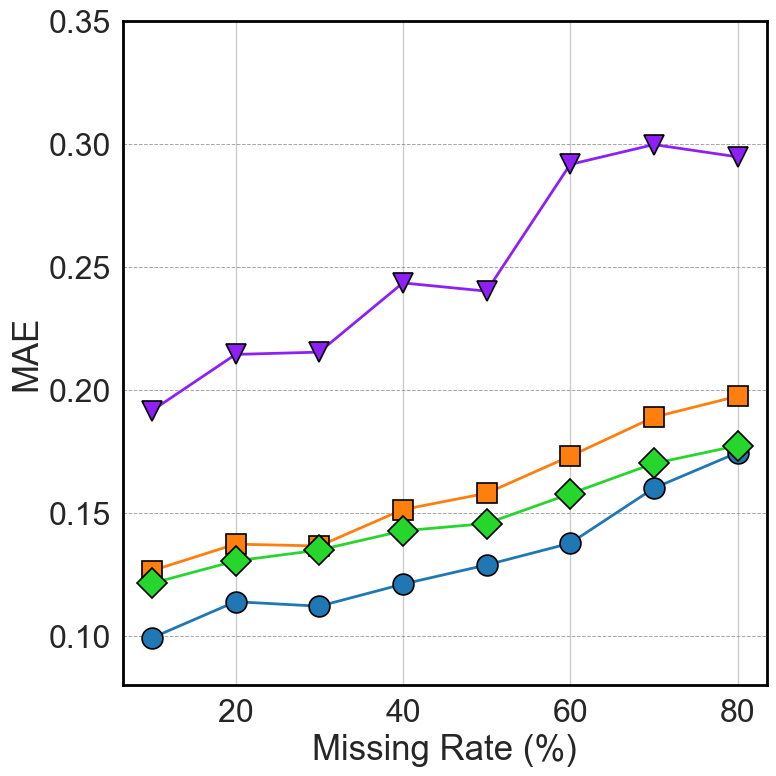

In [19]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_mae.csv"
)

# Keep the same variable name as before
algorithms = df_mae['Algorithm'].unique()
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

plt.figure(figsize=(8, 8))

for algo in algorithms:
    if algo == "MIWAE-U" or algo == "MIWAE-S" or algo == "GAIN-U" or algo == "GAIN-S":
        continue
    df_algo = df_mae[df_mae['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())

    # In case there are multiple rows per (algo, rate), average them (same idea as before)
    mae_values = [df_algo[df_algo['MissingRate'] == mr]['MAE'].mean() for mr in missing_rates]

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, mae_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels (same variables)
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
#plt.title("MAE vs Missing Rate for All Algorithms (MAR)", fontsize=28)

# Legend (kept exactly like your ECE code — commented)
#plt.legend(ncol=2,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges) — same as your ECE code
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines — same as your ECE code
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Keep the same y-limit line as in your ECE plot
ax.set_ylim(0.08, 0.35)

# Tick params — same sizes
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


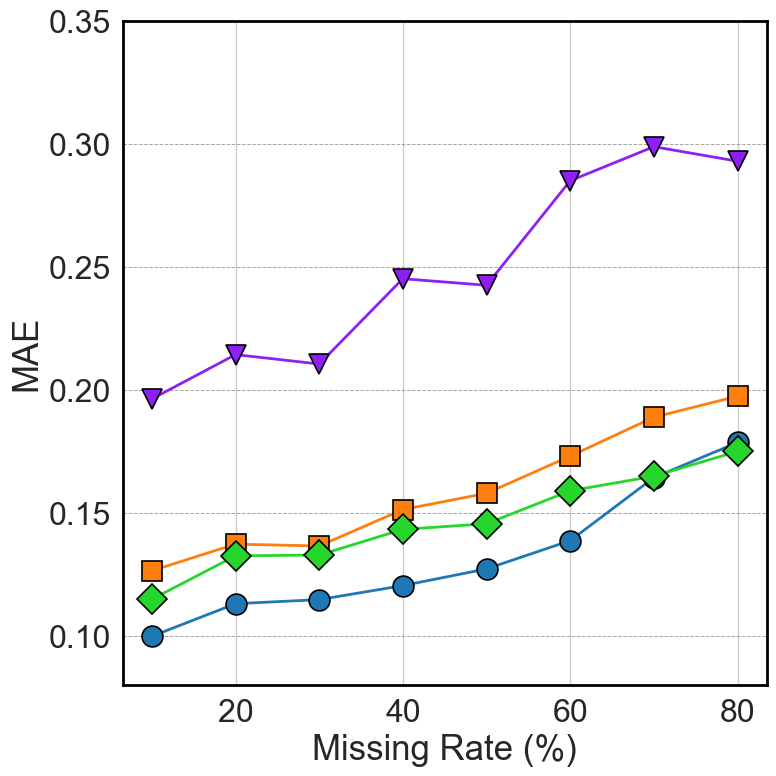

In [20]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_mae.csv"
)

# Keep the same variable name as before
algorithms = df_mae['Algorithm'].unique()
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

plt.figure(figsize=(8, 8))

for algo in algorithms:
    if algo == "MIWAE-U" or algo == "MIWAE-S" or algo == "GAIN-U" or algo == "GAIN-S":
        continue
    df_algo = df_mae[df_mae['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())

    # In case there are multiple rows per (algo, rate), average them (same idea as before)
    mae_values = [df_algo[df_algo['MissingRate'] == mr]['MAE'].mean() for mr in missing_rates]

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, mae_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels (same variables)
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
#plt.title("MAE vs Missing Rate for All Algorithms (MAR)", fontsize=28)

# Legend (kept exactly like your ECE code — commented)
#plt.legend(ncol=2,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges) — same as your ECE code
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines — same as your ECE code
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Keep the same y-limit line as in your ECE plot
ax.set_ylim(0.08, 0.35)

# Tick params — same sizes
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MNAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()
